In [14]:
!pip install pandas numpy ccxt matplotlib yfinance investpy plotly


[notice] A new release of pip is available: 24.0 -> 24.2
[notice] To update, run: python.exe -m pip install --upgrade pip



   ---------------------------------------- 0.0/17.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/17.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/17.3 MB 660.6 kB/s eta 0:00:27
   ---------------------------------------- 0.2/17.3 MB 2.4 MB/s eta 0:00:08
   - -------------------------------------- 0.6/17.3 MB 4.7 MB/s eta 0:00:04
   -- ------------------------------------- 1.1/17.3 MB 6.1 MB/s eta 0:00:03
   --- ------------------------------------ 1.7/17.3 MB 7.8 MB/s eta 0:00:03
   ----- ---------------------------------- 2.5/17.3 MB 9.5 MB/s eta 0:00:02
   -------- ------------------------------- 3.6/17.3 MB 11.4 MB/s eta 0:00:02
   ----------- ---------------------------- 4.8/17.3 MB 13.4 MB/s eta 0:00:01
   -------------- ------------------------- 6.2/17.3 MB 15.3 MB/s eta 0:00:01
   ---------------- ----------------------- 7.3/17.3 MB 16.7 MB/s eta 0:00:01
   ----------------- ---------------------- 7.5/17.3 MB 15.5 MB/s eta 0:00:01
   --

In [48]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# Yahoo Finance data fetch function
def fetch_yahoo_data(ticker, start_date):
    data = yf.download(ticker, start=start_date, interval='1d')
    data.reset_index(inplace=True)
    data.rename(columns={'Date': 'timestamp', 'Close': 'close'}, inplace=True)
    return data

# Derivative products list (Yahoo Finance)
symbols = {
    'Spot': 'QQQ',          # NASDAQ-100 ETF
    'Futures': 'NQ=F'       # NASDAQ-100 Futures
}

# Fetch data
start_date = '2020-01-01'
data = {}

for name, ticker in symbols.items():
    data[name] = fetch_yahoo_data(ticker, start_date)

# Data alignment function
def align_data(data1, data2):
    merged_data = pd.merge(data1, data2, on='timestamp', suffixes=('_spot', '_futures'))
    return merged_data

# Align the data
combined_data = align_data(data['Spot'], data['Futures'])

# Print some sample data for debugging
print(combined_data.head())

[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed

   timestamp   Open_spot   High_spot    Low_spot  close_spot  Adj Close_spot  \
0 2020-01-02  214.399994  216.160004  213.979996  216.160004      210.271164   
1 2020-01-03  213.300003  215.470001  213.279999  214.179993      208.345108   
2 2020-01-06  212.500000  215.589996  212.240005  215.559998      209.687515   
3 2020-01-07  215.639999  216.139999  214.850006  215.529999      209.658340   
4 2020-01-08  215.500000  218.139999  215.160004  217.149994      211.234177   

   Volume_spot  Open_futures  High_futures  Low_futures  close_futures  \
0     30969400       8776.75       8901.50      8769.50        8891.75   
1     27518900       8895.50       8907.25      8735.25        8810.00   
2     21655300       8772.25       8873.00      8723.00        8847.50   
3     22139300       8853.25       8894.75      8825.75        8853.00   
4     26397300       8841.50       8972.25      8678.00        8944.50   

   Adj Close_futures  Volume_futures  
0            8891.75          41663

In [49]:
# Arbitrage opportunity function
def arbitrage_opportunity(spot_prices, futures_prices, threshold, fee_rate, slippage):
    opportunities = []
    total_profit = 0
    cumulative_profit = [0] * len(spot_prices)
    
    for i in range(len(spot_prices) - 1):
        spot_price_today = spot_prices[i]
        futures_price_today = futures_prices[i]
        spot_price_tomorrow = spot_prices[i + 1]
        futures_price_tomorrow = futures_prices[i + 1]
        
        spread_today = futures_price_today - spot_price_today
        spread_tomorrow = futures_price_tomorrow - spot_price_tomorrow
        
        if spread_today > threshold:
            buy_spot_price = spot_price_today * (1 + fee_rate + slippage)
            sell_futures_price = futures_price_today * (1 - fee_rate - slippage)
            sell_spot_price = spot_price_tomorrow * (1 - fee_rate - slippage)
            buy_futures_price = futures_price_tomorrow * (1 + fee_rate + slippage)
            
            profit = (sell_futures_price - buy_spot_price) + (sell_spot_price - buy_futures_price)
            total_profit += profit
            cumulative_profit[i + 1] = cumulative_profit[i] + profit
            opportunities.append((buy_spot_price, sell_futures_price, sell_spot_price, buy_futures_price, profit))
        elif spread_today < -threshold:
            sell_spot_price = spot_price_today * (1 - fee_rate + slippage)
            buy_futures_price = futures_price_today * (1 + fee_rate - slippage)
            buy_spot_price = spot_price_tomorrow * (1 + fee_rate + slippage)
            sell_futures_price = futures_price_tomorrow * (1 - fee_rate - slippage)
            
            profit = (sell_spot_price - buy_futures_price) + (sell_futures_price - buy_spot_price)
            total_profit += profit
            cumulative_profit[i + 1] = cumulative_profit[i] + profit
            opportunities.append((sell_spot_price, buy_futures_price, buy_spot_price, sell_futures_price, profit))
        else:
            cumulative_profit[i + 1] = cumulative_profit[i]
    
    return opportunities, total_profit, cumulative_profit

# Set various arbitrage criteria
thresholds = [5,20, 50]  # Example: 1, 5, 10 points
fee_rate = 0.0005  # Transaction fee (0.05%)
slippage = 0.0005  # Slippage (0.05%)

results = {}
cumulative_profits = {}

for threshold in thresholds:
    spot_prices = combined_data['close_spot'].values
    futures_prices = combined_data['close_futures'].values
    opportunities, total_profit, cumulative_profit = arbitrage_opportunity(spot_prices, futures_prices, threshold, fee_rate, slippage)
    total_trades = len(opportunities)
    average_profit_per_trade = total_profit / total_trades if total_trades > 0 else 0
    results[threshold] = {
        'total_trades': total_trades,
        'total_profit': total_profit,
        'average_profit_per_trade': average_profit_per_trade
    }
    cumulative_profits[threshold] = cumulative_profit

Results for threshold: 5 points
  Total trades: 1160
  Total profit: $-42473.07
  Average profit per trade: $-36.61
Results for threshold: 20 points
  Total trades: 1160
  Total profit: $-42473.07
  Average profit per trade: $-36.61
Results for threshold: 50 points
  Total trades: 1160
  Total profit: $-42473.07
  Average profit per trade: $-36.61


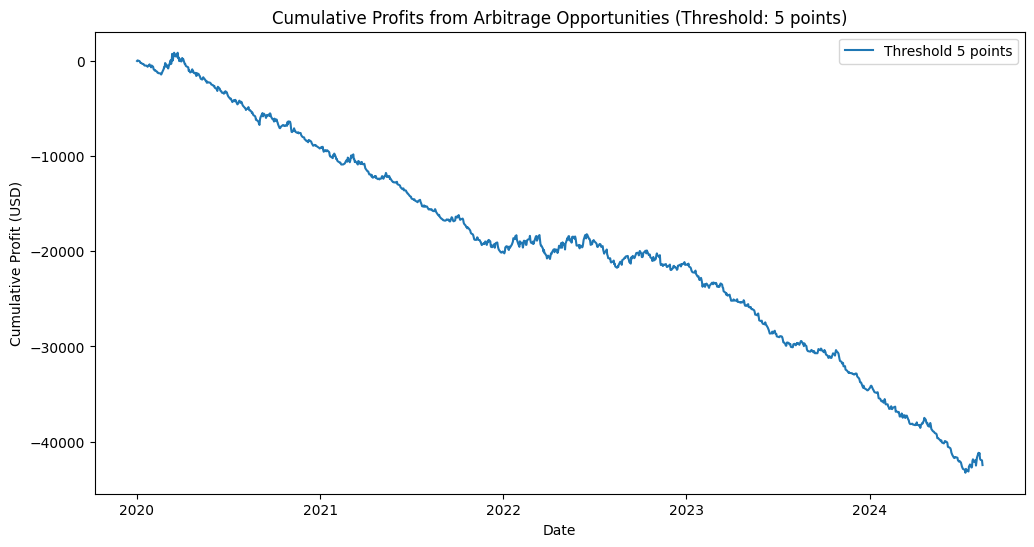

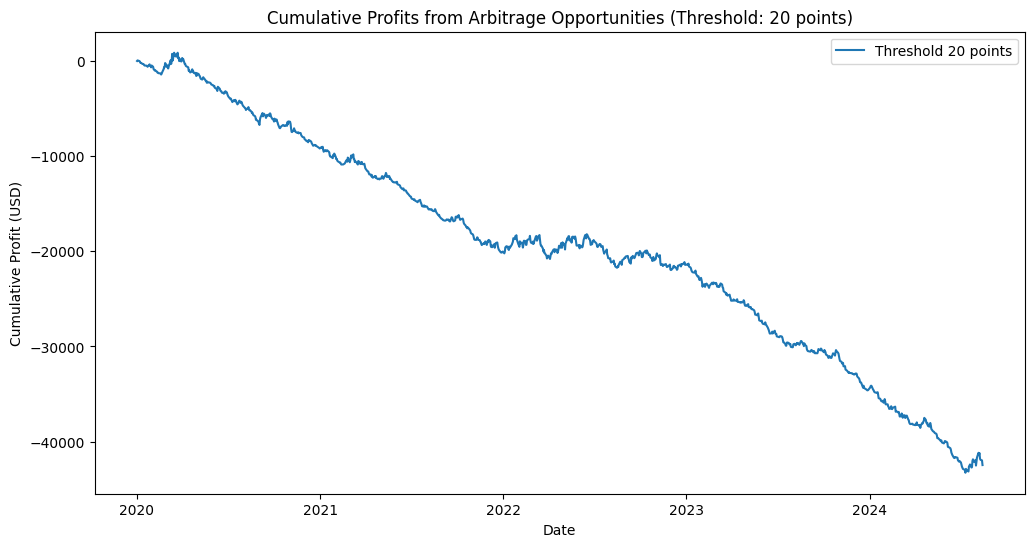

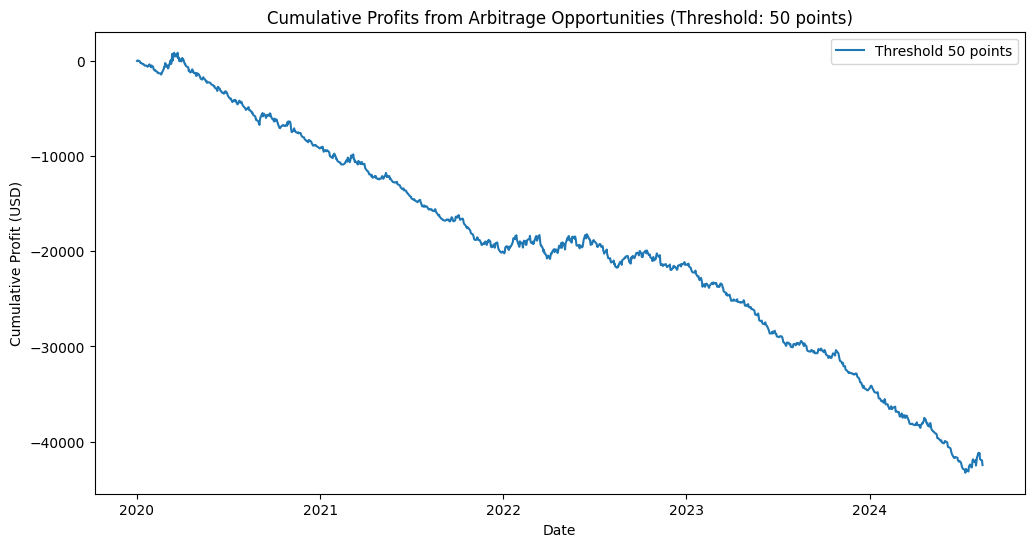

In [50]:
# Display results
for threshold in thresholds:
    print(f"Results for threshold: {threshold} points")
    result = results[threshold]
    print(f"  Total trades: {result['total_trades']}")
    print(f"  Total profit: ${result['total_profit']:.2f}")
    print(f"  Average profit per trade: ${result['average_profit_per_trade']:.2f}")

# Visualization - Cumulative profit
for threshold in thresholds:
    plt.figure(figsize=(12, 6))
    plt.plot(combined_data['timestamp'], cumulative_profits[threshold], label=f'Threshold {threshold} points')
    
    plt.xlabel('Date')
    plt.ylabel('Cumulative Profit (USD)')
    plt.title(f'Cumulative Profits from Arbitrage Opportunities (Threshold: {threshold} points)')
    plt.legend()
    plt.show()

[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed


초기 자본: $100,000.00
최종 자본: $146,287.16
수익률: 46.29%
거래 횟수: 55


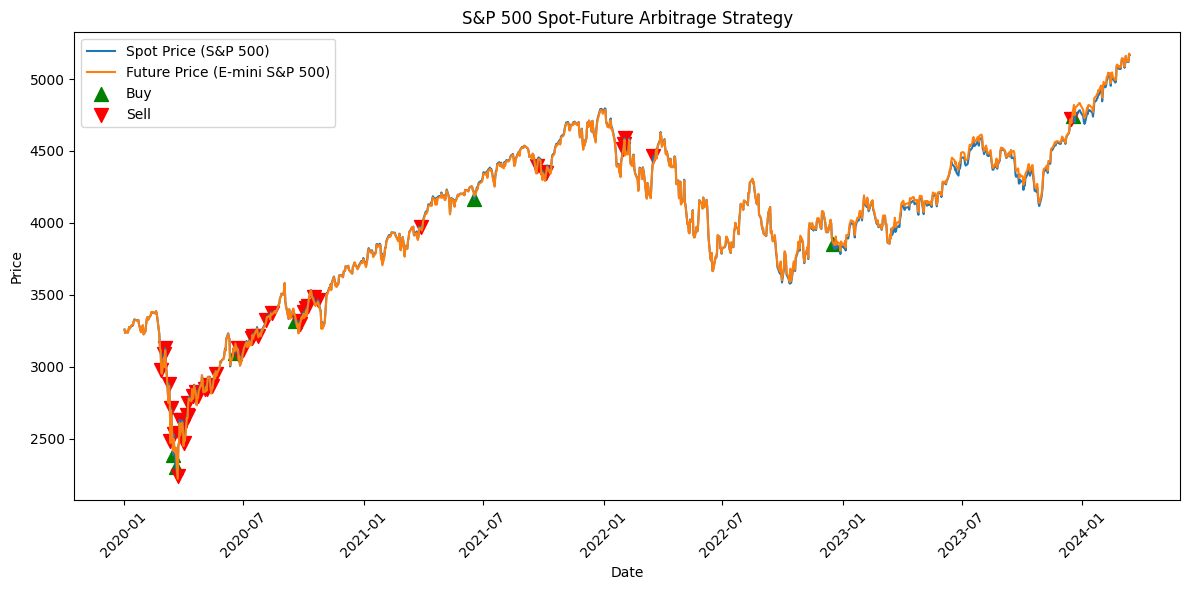

In [52]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 데이터 다운로드
def download_data(ticker, start_date, end_date):
    data = yf.download(ticker, start=start_date, end=end_date)
    return data['Adj Close']

# 파라미터 설정
start_date = '2020-01-01'
end_date = '2024-03-14'
spot_ticker = '^GSPC'
future_ticker = 'ES=F'

# 데이터 다운로드
spot_prices = download_data(spot_ticker, start_date, end_date)
future_prices = download_data(future_ticker, start_date, end_date)

# 데이터 정리
df = pd.DataFrame({'Spot': spot_prices, 'Future': future_prices}).dropna()

# 차익거래 전략 구현
def arbitrage_strategy(df, initial_capital=100000, trade_size=100):
    capital = initial_capital
    position = 0
    trades = []
    
    for date, row in df.iterrows():
        spot = row['Spot']
        future = row['Future']
        
        # 단순화를 위해 고정 스프레드 사용
        spread = future - spot
        avg_spread = df['Future'] - df['Spot']
        spread_std = avg_spread.std()
        
        if spread > avg_spread.mean() + spread_std and position <= 0:
            # 선물 매도, 현물 매수
            trade = min(capital / spot, trade_size)
            capital -= trade * spot
            position += trade
            trades.append((date, trade, 'Buy', spot, future))
        elif spread < avg_spread.mean() - spread_std and position >= 0:
            # 선물 매수, 현물 매도
            trade = min(position, trade_size)
            capital += trade * spot
            position -= trade
            trades.append((date, trade, 'Sell', spot, future))
    
    # 최종 포지션 청산
    final_spot = df['Spot'].iloc[-1]
    capital += position * final_spot
    position = 0
    
    return capital, trades

# 전략 실행
final_capital, trades = arbitrage_strategy(df)

# 결과 분석
initial_capital = 100000
returns = (final_capital - initial_capital) / initial_capital * 100

print(f"초기 자본: ${initial_capital:,.2f}")
print(f"최종 자본: ${final_capital:,.2f}")
print(f"수익률: {returns:.2f}%")
print(f"거래 횟수: {len(trades)}")

# 그래프 그리기
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Spot'], label='Spot Price (S&P 500)')
plt.plot(df.index, df['Future'], label='Future Price (E-mini S&P 500)')
plt.scatter([t[0] for t in trades if t[2] == 'Buy'], 
            [t[3] for t in trades if t[2] == 'Buy'], 
            color='g', marker='^', s=100, label='Buy')
plt.scatter([t[0] for t in trades if t[2] == 'Sell'], 
            [t[3] for t in trades if t[2] == 'Sell'], 
            color='r', marker='v', s=100, label='Sell')
plt.legend()
plt.title('S&P 500 Spot-Future Arbitrage Strategy')
plt.xlabel('Date')
plt.ylabel('Price')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed


초기 자본: $100,000.00
최종 자본: $130,501.29
수익률: 30.50%
거래 횟수: 4


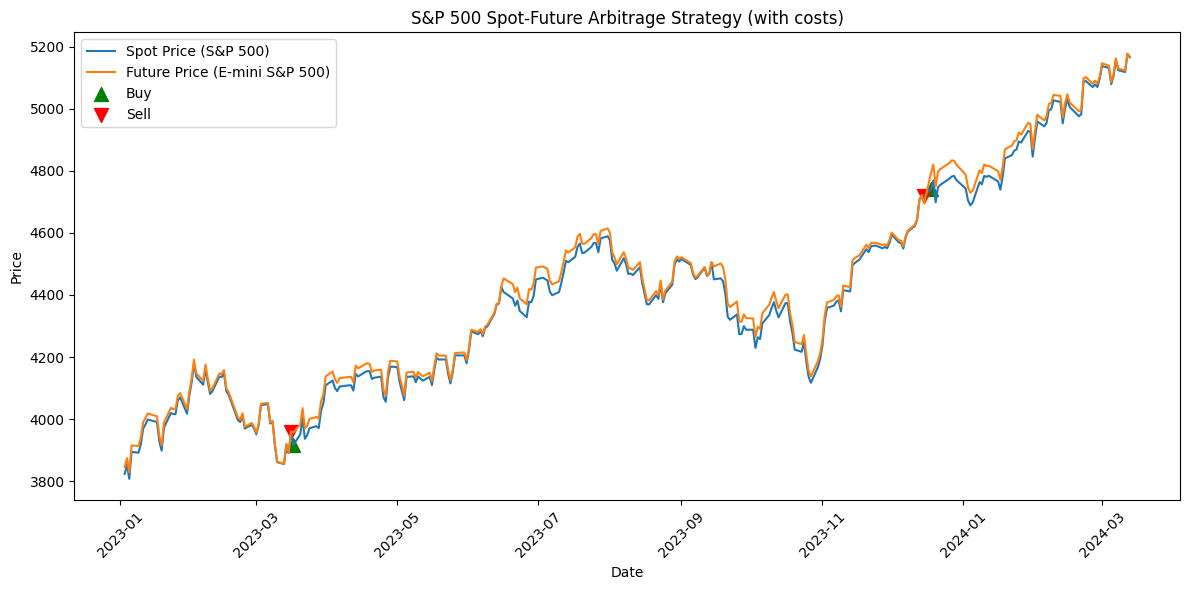

In [53]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 데이터 다운로드
def download_data(ticker, start_date, end_date):
    data = yf.download(ticker, start=start_date, end=end_date)
    return data['Adj Close']

# 파라미터 설정
start_date = '2023-01-01'
end_date = '2024-03-14'
spot_ticker = '^GSPC'
future_ticker = 'ES=F'

# 데이터 다운로드
spot_prices = download_data(spot_ticker, start_date, end_date)
future_prices = download_data(future_ticker, start_date, end_date)

# 데이터 정리
df = pd.DataFrame({'Spot': spot_prices, 'Future': future_prices}).dropna()

# 차익거래 전략 구현
def arbitrage_strategy(df, initial_capital=100000, trade_size=100, commission_rate=0.001, slippage=0.0005):
    capital = initial_capital
    position = 0
    trades = []
    
    for date, row in df.iterrows():
        spot = row['Spot']
        future = row['Future']
        
        # 스프레드 계산
        spread = future - spot
        avg_spread = df['Future'] - df['Spot']
        spread_std = avg_spread.std()
        
        # 거래 비용 계산
        transaction_cost = spot * (commission_rate + slippage)
        
        if spread > avg_spread.mean() + 1.5 * spread_std and position <= 0:
            # 선물 매도, 현물 매수
            trade = min(capital / (spot + transaction_cost), trade_size)
            capital -= trade * (spot + transaction_cost)
            position += trade
            trades.append((date, trade, 'Buy', spot, future))
        elif spread < avg_spread.mean() - 1.5 * spread_std and position >= 0:
            # 선물 매수, 현물 매도
            trade = min(position, trade_size)
            capital += trade * (spot - transaction_cost)
            position -= trade
            trades.append((date, trade, 'Sell', spot, future))
    
    # 최종 포지션 청산
    final_spot = df['Spot'].iloc[-1]
    capital += position * (final_spot - transaction_cost)
    position = 0
    
    return capital, trades

# 전략 실행
final_capital, trades = arbitrage_strategy(df)

# 결과 분석
initial_capital = 100000
returns = (final_capital - initial_capital) / initial_capital * 100

print(f"초기 자본: ${initial_capital:,.2f}")
print(f"최종 자본: ${final_capital:,.2f}")
print(f"수익률: {returns:.2f}%")
print(f"거래 횟수: {len(trades)}")

# 그래프 그리기
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Spot'], label='Spot Price (S&P 500)')
plt.plot(df.index, df['Future'], label='Future Price (E-mini S&P 500)')
plt.scatter([t[0] for t in trades if t[2] == 'Buy'], 
            [t[3] for t in trades if t[2] == 'Buy'], 
            color='g', marker='^', s=100, label='Buy')
plt.scatter([t[0] for t in trades if t[2] == 'Sell'], 
            [t[3] for t in trades if t[2] == 'Sell'], 
            color='r', marker='v', s=100, label='Sell')
plt.legend()
plt.title('S&P 500 Spot-Future Arbitrage Strategy (with costs)')
plt.xlabel('Date')
plt.ylabel('Price')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

[*********************100%%**********************]  2 of 2 completed


DataFrame columns: Index(['ES=F', '^GSPC'], dtype='object', name='Ticker')
DataFrame info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3570 entries, 2010-01-04 to 2024-03-13
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ES=F    3570 non-null   float64
 1   ^GSPC   3570 non-null   float64
dtypes: float64(2)
memory usage: 83.7 KB
None
Improved Arbitrage Strategy Results
Initial Capital: $1,000,000.00
Final Capital: $-236,518.85
Total Return: -123.65
Sharpe Ratio: -0.40
Max Drawdown: 0       124.329876
1       124.329876
2       124.329876
3       124.329876
4       124.329876
           ...    
3566    123.492607
3567    123.492607
3568    123.492607
3569    123.492607
3570    123.492607
Length: 3571, dtype: float64
Number of Trades: 1327.00


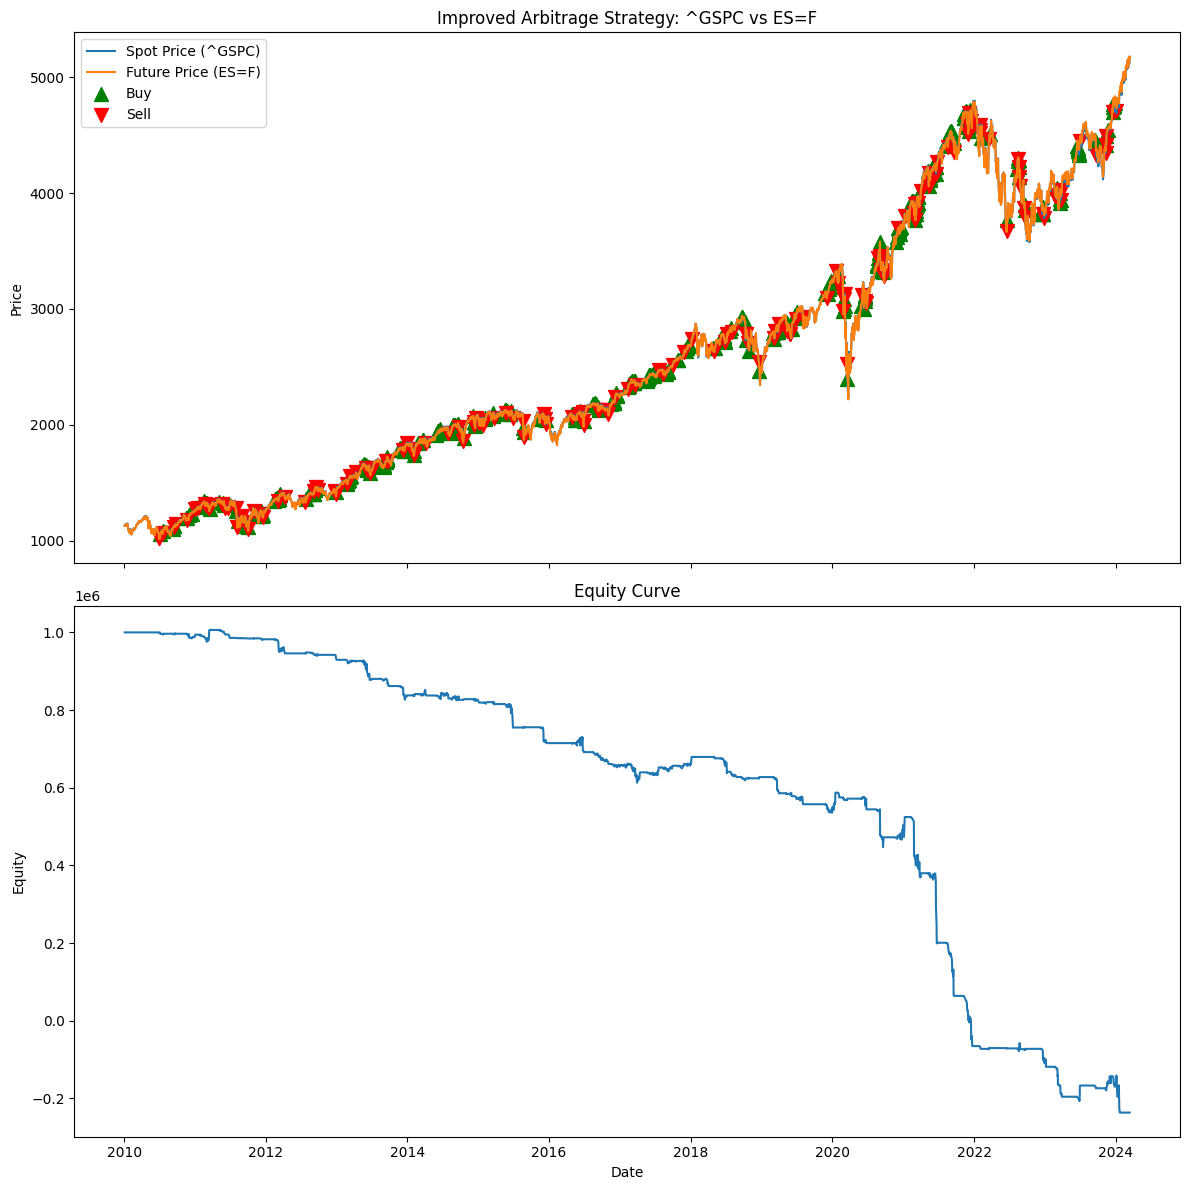

In [26]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from typing import List, Tuple, Dict

class ImprovedArbitrageStrategy:
    def __init__(self, initial_capital: float, max_position: int, 
                 commission_rate: float, slippage: float):
        self.initial_capital = initial_capital
        self.capital = initial_capital
        self.max_position = max_position
        self.commission_rate = commission_rate
        self.slippage = slippage
        self.positions: Dict[str, int] = {}
        self.trades: List[Tuple] = []
        self.equity_curve = []

    def download_data(self, tickers: List[str], start_date: str, end_date: str) -> pd.DataFrame:
        data = yf.download(tickers, start=start_date, end=end_date)['Adj Close']
        return data.dropna()

    def calculate_spread(self, df: pd.DataFrame, spot_col: str, future_col: str) -> pd.Series:
        return df[future_col] - df[spot_col]

    def calculate_position_size(self, spread, mean_spread, std_spread):
        z_score = (spread - mean_spread) / std_spread
        base_position = self.max_position / 2
        position_size = int(base_position * (1 + abs(z_score)))
        return min(position_size, self.max_position)

    def check_stop_loss_take_profit(self, current_price, entry_price, direction, stop_loss_pct=0.01, take_profit_pct=0.02):
        if direction == 'Buy':
            stop_loss = entry_price * (1 - stop_loss_pct)
            take_profit = entry_price * (1 + take_profit_pct)
            return current_price <= stop_loss or current_price >= take_profit
        elif direction == 'Sell':
            stop_loss = entry_price * (1 + stop_loss_pct)
            take_profit = entry_price * (1 - take_profit_pct)
            return current_price >= stop_loss or current_price <= take_profit

    def calculate_multi_period_signals(self, spread, windows=[20, 50, 100]):
        signals = pd.DataFrame()
        for window in windows:
            mean_spread = spread.rolling(window=window).mean()
            std_spread = spread.rolling(window=window).std()
            z_score = (spread - mean_spread) / std_spread
            signals[f'signal_{window}'] = z_score
        return signals.mean(axis=1)

    def adjust_threshold(self, std_spread, base_threshold=1.5, max_threshold=3.0):
        volatility = std_spread.rolling(window=20).mean() / std_spread.rolling(window=100).mean()
        return pd.Series([min(base_threshold * v, max_threshold) for v in volatility], index=std_spread.index)

    def calculate_trend(self, prices, window=50):
        return prices.rolling(window=window).mean().pct_change()

    def optimize_trade_size(self, price, desired_quantity):
        min_trade_cost = price * desired_quantity * self.commission_rate
        if min_trade_cost < 1:  # 최소 거래 비용이 1달러 미만일 경우
            return max(int(1 / (price * self.commission_rate)), desired_quantity)
        return desired_quantity

    def execute_trade(self, date: datetime, asset: str, direction: str, 
                      price: float, quantity: int) -> None:
        optimized_quantity = self.optimize_trade_size(price, quantity)
        transaction_cost = price * optimized_quantity * (self.commission_rate + self.slippage)
        
        if direction == 'Buy':
            self.capital -= price * optimized_quantity + transaction_cost
            self.positions[asset] = self.positions.get(asset, 0) + optimized_quantity
        elif direction == 'Sell':
            self.capital += price * optimized_quantity - transaction_cost
            self.positions[asset] = self.positions.get(asset, 0) - optimized_quantity

        self.trades.append((date, asset, direction, price, optimized_quantity, transaction_cost))

    def calculate_portfolio_value(self, prices: pd.Series) -> float:
        return self.capital + sum(self.positions.get(asset, 0) * prices[asset] for asset in self.positions)

    def run_strategy(self, df: pd.DataFrame, spot_col: str, future_col: str) -> None:
        print("DataFrame columns:", df.columns)
        print("DataFrame info:")
        print(df.info())
        
        spread = self.calculate_spread(df, spot_col, future_col)
        multi_period_signal = self.calculate_multi_period_signals(spread)
        threshold = self.adjust_threshold(spread.rolling(window=20).std())
        trend = self.calculate_trend(df[spot_col])

        for date, row in df.iterrows():
            spot_price = row[spot_col]
            future_price = row[future_col]
            current_spread = future_price - spot_price

            # Check for stop loss / take profit
            for asset, position in list(self.positions.items()):
                if position != 0:
                    entry_price = next(trade[3] for trade in reversed(self.trades) if trade[1] == asset)
                    if self.check_stop_loss_take_profit(row[asset], entry_price, 'Buy' if position > 0 else 'Sell'):
                        self.execute_trade(date, asset, 'Sell' if position > 0 else 'Buy', row[asset], abs(position))

            if abs(multi_period_signal.loc[date]) > threshold.loc[date]:
                position_size = self.calculate_position_size(current_spread, spread.rolling(window=20).mean().loc[date], 
                                                             spread.rolling(window=20).std().loc[date])

                if multi_period_signal.loc[date] > threshold.loc[date] and trend.loc[date] > 0:
                    # Sell future, buy spot
                    self.execute_trade(date, future_col, 'Sell', future_price, position_size)
                    self.execute_trade(date, spot_col, 'Buy', spot_price, position_size)
                elif multi_period_signal.loc[date] < -threshold.loc[date] and trend.loc[date] < 0:
                    # Buy future, sell spot
                    self.execute_trade(date, future_col, 'Buy', future_price, position_size)
                    self.execute_trade(date, spot_col, 'Sell', spot_price, position_size)

            self.equity_curve.append(self.calculate_portfolio_value(row))

    def close_positions(self, df: pd.DataFrame) -> None:
        last_prices = df.iloc[-1]
        for asset, position in self.positions.items():
            if position != 0:
                self.execute_trade(df.index[-1], asset, 'Sell' if position > 0 else 'Buy', 
                                   last_prices[asset], abs(position))
        self.positions.clear()
        self.equity_curve.append(self.capital)

    def calculate_performance(self) -> Dict[str, float]:
        returns = (self.capital - self.initial_capital) / self.initial_capital
        daily_returns = pd.Series(self.equity_curve).pct_change().dropna()
        sharpe_ratio = np.sqrt(252) * daily_returns.mean() / daily_returns.std()
        max_drawdown = (pd.Series(self.equity_curve).cummax() - self.equity_curve).max() / pd.Series(self.equity_curve).cummax()

        return {
            'Total Return': returns * 100,
            'Sharpe Ratio': sharpe_ratio,
            'Max Drawdown': max_drawdown * 100,
            'Number of Trades': len(self.trades)
        }

    def plot_results(self, df: pd.DataFrame, spot_col: str, future_col: str) -> None:
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12), sharex=True)

        ax1.plot(df.index, df[spot_col], label=f'Spot Price ({spot_col})')
        ax1.plot(df.index, df[future_col], label=f'Future Price ({future_col})')
        
        buy_dates = [trade[0] for trade in self.trades if trade[2] == 'Buy' and trade[1] == spot_col]
        buy_prices = [trade[3] for trade in self.trades if trade[2] == 'Buy' and trade[1] == spot_col]
        sell_dates = [trade[0] for trade in self.trades if trade[2] == 'Sell' and trade[1] == spot_col]
        sell_prices = [trade[3] for trade in self.trades if trade[2] == 'Sell' and trade[1] == spot_col]

        ax1.scatter(buy_dates, buy_prices, color='g', marker='^', s=100, label='Buy')
        ax1.scatter(sell_dates, sell_prices, color='r', marker='v', s=100, label='Sell')
        
        ax1.set_ylabel('Price')
        ax1.legend()
        ax1.set_title(f'Improved Arbitrage Strategy: {spot_col} vs {future_col}')

        ax2.plot(df.index, self.equity_curve[:-1])
        ax2.set_ylabel('Equity')
        ax2.set_xlabel('Date')
        ax2.set_title('Equity Curve')

        plt.tight_layout()
        plt.show()

if __name__ == "__main__":
    start_date = '2010-01-01'
    end_date = '2024-03-14'
    spot_ticker = '^GSPC'
    future_ticker = 'ES=F'

    strategy = ImprovedArbitrageStrategy(initial_capital=1000000, max_position=100, 
                                         commission_rate=0.001, slippage=0.0005)
    
    df = strategy.download_data([spot_ticker, future_ticker], start_date, end_date)
    
    strategy.run_strategy(df, spot_ticker, future_ticker)
    strategy.close_positions(df)
    
    performance = strategy.calculate_performance()
    
    print("Improved Arbitrage Strategy Results")
    print("===================================")
    print(f"Initial Capital: ${strategy.initial_capital:,.2f}")
    print(f"Final Capital: ${strategy.capital:,.2f}")
    for metric, value in performance.items():
        if isinstance(value, (int, float)):
            print(f"{metric}: {value:.2f}")
        else:
            print(f"{metric}: {value}")
    
    strategy.plot_results(df, spot_ticker, future_ticker)

In [6]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def download_data(tickers, start_date, end_date):
    data = yf.download(tickers, start=start_date, end=end_date)['Adj Close']
    return data.dropna()

start_date = '2023-01-01'
end_date = '2024-03-14'
spot_ticker = '^GSPC'
future_ticker = 'ES=F'

df = download_data([spot_ticker, future_ticker], start_date, end_date)
print(df.head())

[*********************100%%**********************]  2 of 2 completed

Ticker         ES=F        ^GSPC
Date                            
2023-01-03  3846.00  3824.139893
2023-01-04  3874.50  3852.969971
2023-01-05  3829.00  3808.100098
2023-01-06  3915.50  3895.080078
2023-01-09  3913.75  3892.090088


In [7]:
def analyze_market_conditions(df):
    # 20일 이동평균을 기준으로 시장 상황 판단
    df['MA20'] = df[spot_ticker].rolling(window=20).mean()
    df['Market_Condition'] = np.where(df[spot_ticker] > df['MA20'] * 1.05, 'Bull',
                                      np.where(df[spot_ticker] < df['MA20'] * 0.95, 'Bear', 'Sideways'))
    
    # 각 시장 상황별 성과 분석
    for condition in ['Bull', 'Bear', 'Sideways']:
        condition_df = df[df['Market_Condition'] == condition]
        condition_returns = calculate_returns(condition_df)
        print(f"{condition} Market Performance:")
        print(f"Average Return: {condition_returns.mean():.2%}")
        print(f"Volatility: {condition_returns.std():.2%}")
        print()

analyze_market_conditions(df)

NameError: name 'calculate_returns' is not defined

In [8]:
def calculate_performance_metrics(returns):
    annualized_return = returns.mean() * 252
    annualized_volatility = returns.std() * np.sqrt(252)
    sharpe_ratio = annualized_return / annualized_volatility
    max_drawdown = (returns.cummax() - returns).max()
    
    print(f"Annualized Return: {annualized_return:.2%}")
    print(f"Annualized Volatility: {annualized_volatility:.2%}")
    print(f"Sharpe Ratio: {sharpe_ratio:.2f}")
    print(f"Maximum Drawdown: {max_drawdown:.2%}")

returns = calculate_returns(df)
calculate_performance_metrics(returns)

NameError: name 'calculate_returns' is not defined

In [9]:
def calculate_position_size(account_size, risk_per_trade, stop_loss_percent):
    max_loss_amount = account_size * risk_per_trade
    position_size = max_loss_amount / stop_loss_percent
    return position_size

# 예: $100,000 계좌, 거래당 1% 리스크, 2% 손절매
position_size = calculate_position_size(100000, 0.01, 0.02)
print(f"Recommended Position Size: ${position_size:.2f}")

Recommended Position Size: $50000.00


In [10]:
def apply_stop_loss_take_profit(df, stop_loss_pct, take_profit_pct):
    df['Stop_Loss'] = df['Entry_Price'] * (1 - stop_loss_pct)
    df['Take_Profit'] = df['Entry_Price'] * (1 + take_profit_pct)
    
    for i in range(1, len(df)):
        if df['Position'].iloc[i-1] != 0:
            if df['Low'].iloc[i] <= df['Stop_Loss'].iloc[i-1]:
                df['Position'].iloc[i] = 0
                df['Exit_Price'].iloc[i] = df['Stop_Loss'].iloc[i-1]
            elif df['High'].iloc[i] >= df['Take_Profit'].iloc[i-1]:
                df['Position'].iloc[i] = 0
                df['Exit_Price'].iloc[i] = df['Take_Profit'].iloc[i-1]
    
    return df

df = apply_stop_loss_take_profit(df, stop_loss_pct=0.02, take_profit_pct=0.03)

KeyError: 'Entry_Price'

In [11]:
def apply_trading_costs(df, commission_pct=0.001, slippage_pct=0.0005):
    df['Entry_Cost'] = df['Entry_Price'] * (commission_pct + slippage_pct)
    df['Exit_Cost'] = df['Exit_Price'] * (commission_pct + slippage_pct)
    df['Net_Profit'] = (df['Exit_Price'] - df['Entry_Price']) * df['Position'] - df['Entry_Cost'] - df['Exit_Cost']
    return df

df = apply_trading_costs(df)

KeyError: 'Entry_Price'

In [12]:
import websocket
import json

def on_message(ws, message):
    data = json.loads(message)
    # 실시간 데이터 처리 로직
    print(f"Received data: {data}")

def on_error(ws, error):
    print(f"Error: {error}")

def on_close(ws):
    print("Connection closed")

def on_open(ws):
    print("Connection opened")
    # 구독 요청 보내기
    subscribe_message = json.dumps({"type": "subscribe", "symbol": "AAPL"})
    ws.send(subscribe_message)

websocket.enableTrace(True)
ws = websocket.WebSocketApp("wss://example.com/ws",
                            on_message = on_message,
                            on_error = on_error,
                            on_close = on_close)
ws.on_open = on_open
ws.run_forever()

ModuleNotFoundError: No module named 'websocket'

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 수익률 분포 히스토그램
plt.figure(figsize=(10, 6))
sns.histplot(returns, kde=True)
plt.title('Distribution of Returns')
plt.xlabel('Daily Returns')
plt.ylabel('Frequency')
plt.show()

# 누적 수익률 곡선
cumulative_returns = (1 + returns).cumprod()
plt.figure(figsize=(12, 6))
plt.plot(cumulative_returns.index, cumulative_returns)
plt.title('Cumulative Returns')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.show()

# 드로다운 차트
drawdown = (cumulative_returns.cummax() - cumulative_returns) / cumulative_returns.cummax()
plt.figure(figsize=(12, 6))
plt.fill_between(drawdown.index, drawdown, 0, alpha=0.3)
plt.title('Drawdown')
plt.xlabel('Date')
plt.ylabel('Drawdown')
plt.show()

In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# 캔들스틱 차트와 거래 신호를 함께 표시
fig = make_subplots(rows=2, cols=1, shared_xaxes=True, vertical_spacing=0.03, row_heights=[0.7, 0.3])

fig.add_trace(go.Candlestick(x=df.index,
                open=df['Open'],
                high=df['High'],
                low=df['Low'],
                close=df['Close'],
                name='Price'))

fig.add_trace(go.Scatter(x=df.index, y=df['Signal'], name='Trading Signal'), row=2, col=1)

fig.update_layout(title='S&P 500 Price and Trading Signals',
                  yaxis_title='Price',
                  yaxis2_title='Signal')

fig.show()

In [24]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from datetime import datetime, timedelta
from typing import List, Tuple, Dict

class ImprovedArbitrageStrategy:
    def __init__(self, initial_capital: float, max_position: int, 
                 commission_rate: float, slippage: float):
        self.initial_capital = initial_capital
        self.capital = initial_capital
        self.max_position = max_position
        self.commission_rate = commission_rate
        self.slippage = slippage
        self.positions: Dict[str, int] = {}
        self.trades: List[Tuple] = []
        self.equity_curve = []

    def download_data(self, tickers: List[str], start_date: str, end_date: str) -> pd.DataFrame:
        data = yf.download(tickers, start=start_date, end=end_date)
        print("Downloaded data columns:", data.columns)
        print("Downloaded data info:")
        print(data.info())
        
        # 열 이름 재구성
        new_columns = {}
        for column in data.columns:
            if isinstance(column, tuple):
                new_columns[column] = f"{column[1]}_{column[0]}"
            else:
                new_columns[column] = column
        
        data.rename(columns=new_columns, inplace=True)
        
        print("Modified data columns:", data.columns)
        return data

    def calculate_spread(self, df: pd.DataFrame, spot_col: str, future_col: str) -> pd.Series:
        return df[future_col] - df[spot_col]

    def calculate_position_size(self, spread, mean_spread, std_spread):
        z_score = (spread - mean_spread) / std_spread
        base_position = self.max_position / 2
        position_size = int(base_position * (1 + abs(z_score)))
        return min(position_size, self.max_position)

    def check_stop_loss_take_profit(self, current_price, entry_price, direction, stop_loss_pct=0.01, take_profit_pct=0.02):
        if direction == 'Buy':
            stop_loss = entry_price * (1 - stop_loss_pct)
            take_profit = entry_price * (1 + take_profit_pct)
            return current_price <= stop_loss or current_price >= take_profit
        elif direction == 'Sell':
            stop_loss = entry_price * (1 + stop_loss_pct)
            take_profit = entry_price * (1 - take_profit_pct)
            return current_price >= stop_loss or current_price <= take_profit

    def calculate_multi_period_signals(self, spread, windows=[20, 50, 100]):
        signals = []
        for window in windows:
            mean_spread = spread.rolling(window=window).mean()
            std_spread = spread.rolling(window=window).std()
            z_score = (spread - mean_spread) / std_spread
            signals.append(z_score)
        return pd.DataFrame(signals).mean()

    def adjust_threshold(self, std_spread, base_threshold=1.5, max_threshold=3.0):
        volatility = std_spread.rolling(window=20).mean() / std_spread.rolling(window=100).mean()
        return pd.Series([min(base_threshold * v, max_threshold) for v in volatility], index=std_spread.index)

    def calculate_trend(self, prices, window=50):
        return prices.rolling(window=window).mean().pct_change()

    def optimize_trade_size(self, price, desired_quantity):
        min_trade_cost = price * desired_quantity * self.commission_rate
        if min_trade_cost < 1:  # 최소 거래 비용이 1달러 미만일 경우
            return max(int(1 / (price * self.commission_rate)), desired_quantity)
        return desired_quantity

    def execute_trade(self, date: datetime, asset: str, direction: str, 
                      price: float, quantity: int) -> None:
        optimized_quantity = self.optimize_trade_size(price, quantity)
        transaction_cost = price * optimized_quantity * (self.commission_rate + self.slippage)
        
        if direction == 'Buy':
            self.capital -= price * optimized_quantity + transaction_cost
            self.positions[asset] = self.positions.get(asset, 0) + optimized_quantity
        elif direction == 'Sell':
            self.capital += price * optimized_quantity - transaction_cost
            self.positions[asset] = self.positions.get(asset, 0) - optimized_quantity

        self.trades.append((date, asset, direction, price, optimized_quantity, transaction_cost))

    def calculate_portfolio_value(self, prices: pd.Series) -> float:
        return self.capital + sum(self.positions.get(asset, 0) * prices[f'{asset}_Close'] for asset in self.positions)

    def run_strategy(self, df: pd.DataFrame, spot_col: str, future_col: str) -> None:
        print("DataFrame columns:", df.columns)
        print("DataFrame info:")
        print(df.info())
        
        spot_close = f"{spot_col}_Close" if f"{spot_col}_Close" in df.columns else "Close"
        future_close = f"{future_col}_Close" if f"{future_col}_Close" in df.columns else "Close"
        
        spread = self.calculate_spread(df, spot_close, future_close)
        multi_period_signal = self.calculate_multi_period_signals(spread)
        threshold = self.adjust_threshold(spread.rolling(window=20).std())
        trend = self.calculate_trend(df[spot_close])

        for date, row in df.iterrows():
            spot_price = row[spot_close]
            future_price = row[future_close]
            current_spread = future_price - spot_price

            # Check for stop loss / take profit
            for asset, position in list(self.positions.items()):
                if position != 0:
                    entry_price = next(trade[3] for trade in reversed(self.trades) if trade[1] == asset)
                    if self.check_stop_loss_take_profit(row[f'{asset}_Close'], entry_price, 'Buy' if position > 0 else 'Sell'):
                        self.execute_trade(date, asset, 'Sell' if position > 0 else 'Buy', row[f'{asset}_Close'], abs(position))

            if abs(multi_period_signal.loc[date]) > threshold.loc[date]:
                position_size = self.calculate_position_size(current_spread, spread.rolling(window=20).mean().loc[date], 
                                                             spread.rolling(window=20).std().loc[date])

                if multi_period_signal.loc[date] > threshold.loc[date] and trend.loc[date] > 0:
                    # Sell future, buy spot
                    self.execute_trade(date, future_col, 'Sell', future_price, position_size)
                    self.execute_trade(date, spot_col, 'Buy', spot_price, position_size)
                elif multi_period_signal.loc[date] < -threshold.loc[date] and trend.loc[date] < 0:
                    # Buy future, sell spot
                    self.execute_trade(date, future_col, 'Buy', future_price, position_size)
                    self.execute_trade(date, spot_col, 'Sell', spot_price, position_size)

            self.equity_curve.append(self.calculate_portfolio_value(row))

    def close_positions(self, df: pd.DataFrame) -> None:
        last_prices = df.iloc[-1]
        for asset, position in self.positions.items():
            if position != 0:
                self.execute_trade(df.index[-1], asset, 'Sell' if position > 0 else 'Buy', 
                                   last_prices[f'{asset}_Close'], abs(position))
        self.positions.clear()
        self.equity_curve.append(self.capital)

    def calculate_performance(self) -> Dict[str, float]:
        returns = (self.capital - self.initial_capital) / self.initial_capital
        daily_returns = pd.Series(self.equity_curve).pct_change().dropna()
        sharpe_ratio = np.sqrt(252) * daily_returns.mean() / daily_returns.std()
        max_drawdown = (pd.Series(self.equity_curve).cummax() - self.equity_curve).max() / pd.Series(self.equity_curve).cummax()

        return {
            'Total Return': returns * 100,
            'Sharpe Ratio': sharpe_ratio,
            'Max Drawdown': max_drawdown * 100,
            'Number of Trades': len(self.trades)
        }

    def plot_results(self, df: pd.DataFrame, spot_col: str, future_col: str) -> None:
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12), sharex=True)

        ax1.plot(df.index, df[f'{spot_col}_Close'], label=f'Spot Price ({spot_col})')
        ax1.plot(df.index, df[f'{future_col}_Close'], label=f'Future Price ({future_col})')
        
        buy_dates = [trade[0] for trade in self.trades if trade[2] == 'Buy' and trade[1] == spot_col]
        buy_prices = [trade[3] for trade in self.trades if trade[2] == 'Buy' and trade[1] == spot_col]
        sell_dates = [trade[0] for trade in self.trades if trade[2] == 'Sell' and trade[1] == spot_col]
        sell_prices = [trade[3] for trade in self.trades if trade[2] == 'Sell' and trade[1] == spot_col]

        ax1.scatter(buy_dates, buy_prices, color='g', marker='^', s=100, label='Buy')
        ax1.scatter(sell_dates, sell_prices, color='r', marker='v', s=100, label='Sell')
        
        ax1.set_ylabel('Price')
        ax1.legend()
        ax1.set_title(f'Improved Arbitrage Strategy: {spot_col} vs {future_col}')

        ax2.plot(df.index, self.equity_curve[:-1])
        ax2.set_ylabel('Equity')
        ax2.set_xlabel('Date')
        ax2.set_title('Equity Curve')

        plt.tight_layout()
        plt.show()

    def plot_additional_charts(self, returns):
        # 수익률 분포 히스토그램
        plt.figure(figsize=(10, 6))
        sns.histplot(returns, kde=True)
        plt.title('Distribution of Returns')
        plt.xlabel('Daily Returns')
        plt.ylabel('Frequency')
        plt.show()

        # 누적 수익률 곡선
        cumulative_returns = (1 + returns).cumprod()
        plt.figure(figsize=(12, 6))
        plt.plot(cumulative_returns.index, cumulative_returns)
        plt.title('Cumulative Returns')
        plt.xlabel('Date')
        plt.ylabel('Cumulative Return')
        plt.show()

        # 드로다운 차트
        drawdown = (cumulative_returns.cummax() - cumulative_returns) / cumulative_returns.cummax()
        plt.figure(figsize=(12, 6))
        plt.fill_between(drawdown.index, drawdown, 0, alpha=0.3)
        plt.title('Drawdown')
        plt.xlabel('Date')
        plt.ylabel('Drawdown')
        plt.show()

    def plot_interactive_chart(self, df: pd.DataFrame, spot_col: str, future_col: str):
        fig = make_subplots(rows=2, cols=1, shared_xaxes=True, vertical_spacing=0.03, row_heights=[0.7, 0.3])

        fig.add_trace(go.Candlestick(x=df.index,
                        open=df[f'{spot_col}_Open'],
                        high=df[f'{spot_col}_High'],
                        low=df[f'{spot_col}_Low'],
                        close=df[f'{spot_col}_Close'],
                        name='Spot Price'))

        fig.add_trace(go.Scatter(x=df.index, y=df[f'{future_col}_Close'], name='Future Price'))

        buy_dates = [trade[0] for trade in self.trades if trade[2] == 'Buy' and trade[1] == spot_col]
        buy_prices = [trade[3] for trade in self.trades if trade[2] == 'Buy' and trade[1] == spot_col]
        sell_dates = [trade[0] for trade in self.trades if trade[2] == 'Sell' and trade[1] == spot_col]
        sell_prices = [trade[3] for trade in self.trades if trade[2] == 'Sell' and trade[1] == spot_col]

        fig.add_trace(go.Scatter(x=buy_dates, y=buy_prices, mode='markers', 
                                 marker=dict(symbol='triangle-up', size=10, color='green'), name='Buy'))
        fig.add_trace(go.Scatter(x=sell_dates, y=sell_prices, mode='markers', 
                                 marker=dict(symbol='triangle-down', size=10, color='red'), name='Sell'))

        fig.add_trace(go.Scatter(x=df.index, y=self.equity_curve[:-1], name='Equity Curve'), row=2, col=1)

        fig.update_layout(title='S&P 500 Arbitrage Strategy',
                          yaxis_title='Price',
                          yaxis2_title='Equity')

        fig.show()

if __name__ == "__main__":
    start_date = '2010-01-01'
    end_date = '2024-03-14'
    spot_ticker = '^GSPC'
    future_ticker = 'ES=F'

    strategy = ImprovedArbitrageStrategy(initial_capital=1000000, max_position=100, 
                                         commission_rate=0.001, slippage=0.0005)
    
    df = strategy.download_data([spot_ticker, future_ticker], start_date, end_date)
    
    # 데이터프레임 구조 확인
    print("Final DataFrame columns:", df.columns)
    print("Final DataFrame info:")
    print(df.info())

    # 열 이름 확인 후 적절한 이름으로 전략 실행
    strategy.run_strategy(df, spot_ticker, future_ticker)
    strategy.close_positions(df)
    
    performance = strategy.calculate_performance()
    
    print("Improved Arbitrage Strategy Results")
    print("===================================")
    print(f"Initial Capital: ${strategy.initial_capital:,.2f}")
    print(f"Final Capital: ${strategy.capital:,.2f}")
    for metric, value in performance.items():
        if isinstance(value, (int, float)):
            print(f"{metric}: {value:.2f}")
        else:
            print(f"{metric}: {value}")
    
    strategy.plot_results(df, spot_ticker, future_ticker)
    
    returns = pd.Series

[*********************100%%**********************]  2 of 2 completed

Downloaded data columns: MultiIndex([('Adj Close',  'ES=F'),
            ('Adj Close', '^GSPC'),
            (    'Close',  'ES=F'),
            (    'Close', '^GSPC'),
            (     'High',  'ES=F'),
            (     'High', '^GSPC'),
            (      'Low',  'ES=F'),
            (      'Low', '^GSPC'),
            (     'Open',  'ES=F'),
            (     'Open', '^GSPC'),
            (   'Volume',  'ES=F'),
            (   'Volume', '^GSPC')],
           names=['Price', 'Ticker'])
Downloaded data info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3573 entries, 2010-01-04 to 2024-03-13
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   (Adj Close, ES=F)   3571 non-null   float64
 1   (Adj Close, ^GSPC)  3572 non-null   float64
 2   (Close, ES=F)       3571 non-null   float64
 3   (Close, ^GSPC)      3572 non-null   float64
 4   (High, ES=F)        3571 non-null   float64
 5   (High, ^G

ValueError: Must pass 2-d input. shape=(3, 3573, 2)

[*********************100%%**********************]  2 of 2 completed


DataFrame columns: Index(['ES=F', '^GSPC'], dtype='object', name='Ticker')
DataFrame info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3570 entries, 2010-01-04 to 2024-03-13
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ES=F    3570 non-null   float64
 1   ^GSPC   3570 non-null   float64
dtypes: float64(2)
memory usage: 83.7 KB
None
Improved Arbitrage Strategy Results
Initial Capital: $1,000,000.00
Final Capital: $-236,518.85
Total Return: -123.65
Sharpe Ratio: -0.40
Max Drawdown: 0       124.329876
1       124.329876
2       124.329876
3       124.329876
4       124.329876
           ...    
3566    123.492607
3567    123.492607
3568    123.492607
3569    123.492607
3570    123.492607
Length: 3571, dtype: float64
Number of Trades: 1327.00


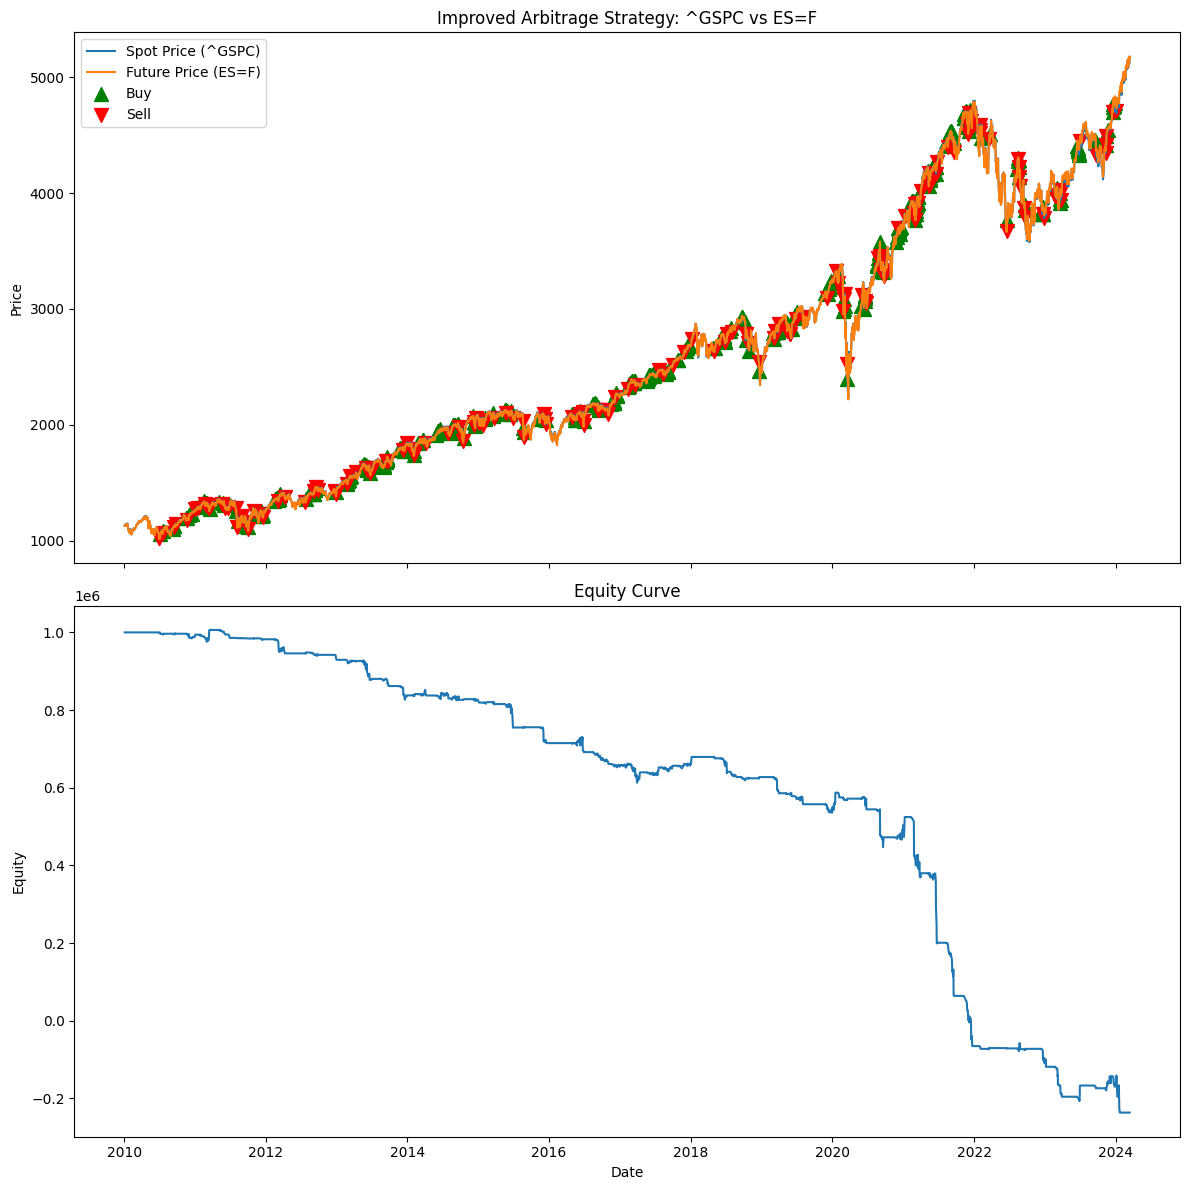

In [27]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from typing import List, Tuple, Dict

class ImprovedArbitrageStrategy:
    def __init__(self, initial_capital: float, max_position: int, 
                 commission_rate: float, slippage: float):
        self.initial_capital = initial_capital
        self.capital = initial_capital
        self.max_position = max_position
        self.commission_rate = commission_rate
        self.slippage = slippage
        self.positions: Dict[str, int] = {}
        self.trades: List[Tuple] = []
        self.equity_curve = []

    def download_data(self, tickers: List[str], start_date: str, end_date: str) -> pd.DataFrame:
        data = yf.download(tickers, start=start_date, end=end_date)['Adj Close']
        return data.dropna()

    def calculate_spread(self, df: pd.DataFrame, spot_col: str, future_col: str) -> pd.Series:
        return df[future_col] - df[spot_col]

    def calculate_position_size(self, spread, mean_spread, std_spread):
        z_score = (spread - mean_spread) / std_spread
        base_position = self.max_position / 2
        position_size = int(base_position * (1 + abs(z_score)))
        return min(position_size, self.max_position)

    def check_stop_loss_take_profit(self, current_price, entry_price, direction, stop_loss_pct=0.01, take_profit_pct=0.02):
        if direction == 'Buy':
            stop_loss = entry_price * (1 - stop_loss_pct)
            take_profit = entry_price * (1 + take_profit_pct)
            return current_price <= stop_loss or current_price >= take_profit
        elif direction == 'Sell':
            stop_loss = entry_price * (1 + stop_loss_pct)
            take_profit = entry_price * (1 - take_profit_pct)
            return current_price >= stop_loss or current_price <= take_profit

    def calculate_multi_period_signals(self, spread, windows=[20, 50, 100]):
        signals = pd.DataFrame()
        for window in windows:
            mean_spread = spread.rolling(window=window).mean()
            std_spread = spread.rolling(window=window).std()
            z_score = (spread - mean_spread) / std_spread
            signals[f'signal_{window}'] = z_score
        return signals.mean(axis=1)

    def adjust_threshold(self, std_spread, base_threshold=1.5, max_threshold=3.0):
        volatility = std_spread.rolling(window=20).mean() / std_spread.rolling(window=100).mean()
        return pd.Series([min(base_threshold * v, max_threshold) for v in volatility], index=std_spread.index)

    def calculate_trend(self, prices, window=50):
        return prices.rolling(window=window).mean().pct_change()

    def optimize_trade_size(self, price, desired_quantity):
        min_trade_cost = price * desired_quantity * self.commission_rate
        if min_trade_cost < 1:  # 최소 거래 비용이 1달러 미만일 경우
            return max(int(1 / (price * self.commission_rate)), desired_quantity)
        return desired_quantity

    def execute_trade(self, date: datetime, asset: str, direction: str, 
                      price: float, quantity: int) -> None:
        optimized_quantity = self.optimize_trade_size(price, quantity)
        transaction_cost = price * optimized_quantity * (self.commission_rate + self.slippage)
        
        if direction == 'Buy':
            self.capital -= price * optimized_quantity + transaction_cost
            self.positions[asset] = self.positions.get(asset, 0) + optimized_quantity
        elif direction == 'Sell':
            self.capital += price * optimized_quantity - transaction_cost
            self.positions[asset] = self.positions.get(asset, 0) - optimized_quantity

        self.trades.append((date, asset, direction, price, optimized_quantity, transaction_cost))

    def calculate_portfolio_value(self, prices: pd.Series) -> float:
        return self.capital + sum(self.positions.get(asset, 0) * prices[asset] for asset in self.positions)

    def run_strategy(self, df: pd.DataFrame, spot_col: str, future_col: str) -> None:
        print("DataFrame columns:", df.columns)
        print("DataFrame info:")
        print(df.info())
        
        spread = self.calculate_spread(df, spot_col, future_col)
        multi_period_signal = self.calculate_multi_period_signals(spread)
        threshold = self.adjust_threshold(spread.rolling(window=20).std())
        trend = self.calculate_trend(df[spot_col])

        for date, row in df.iterrows():
            spot_price = row[spot_col]
            future_price = row[future_col]
            current_spread = future_price - spot_price

            # Check for stop loss / take profit
            for asset, position in list(self.positions.items()):
                if position != 0:
                    entry_price = next(trade[3] for trade in reversed(self.trades) if trade[1] == asset)
                    if self.check_stop_loss_take_profit(row[asset], entry_price, 'Buy' if position > 0 else 'Sell'):
                        self.execute_trade(date, asset, 'Sell' if position > 0 else 'Buy', row[asset], abs(position))

            if abs(multi_period_signal.loc[date]) > threshold.loc[date]:
                position_size = self.calculate_position_size(current_spread, spread.rolling(window=20).mean().loc[date], 
                                                             spread.rolling(window=20).std().loc[date])

                if multi_period_signal.loc[date] > threshold.loc[date] and trend.loc[date] > 0:
                    # Sell future, buy spot
                    self.execute_trade(date, future_col, 'Sell', future_price, position_size)
                    self.execute_trade(date, spot_col, 'Buy', spot_price, position_size)
                elif multi_period_signal.loc[date] < -threshold.loc[date] and trend.loc[date] < 0:
                    # Buy future, sell spot
                    self.execute_trade(date, future_col, 'Buy', future_price, position_size)
                    self.execute_trade(date, spot_col, 'Sell', spot_price, position_size)

            self.equity_curve.append(self.calculate_portfolio_value(row))

    def close_positions(self, df: pd.DataFrame) -> None:
        last_prices = df.iloc[-1]
        for asset, position in self.positions.items():
            if position != 0:
                self.execute_trade(df.index[-1], asset, 'Sell' if position > 0 else 'Buy', 
                                   last_prices[asset], abs(position))
        self.positions.clear()
        self.equity_curve.append(self.capital)

    def calculate_performance(self) -> Dict[str, float]:
        returns = (self.capital - self.initial_capital) / self.initial_capital
        daily_returns = pd.Series(self.equity_curve).pct_change().dropna()
        sharpe_ratio = np.sqrt(252) * daily_returns.mean() / daily_returns.std()
        max_drawdown = (pd.Series(self.equity_curve).cummax() - self.equity_curve).max() / pd.Series(self.equity_curve).cummax()

        return {
            'Total Return': returns * 100,
            'Sharpe Ratio': sharpe_ratio,
            'Max Drawdown': max_drawdown * 100,
            'Number of Trades': len(self.trades)
        }

    def plot_results(self, df: pd.DataFrame, spot_col: str, future_col: str) -> None:
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12), sharex=True)

        ax1.plot(df.index, df[spot_col], label=f'Spot Price ({spot_col})')
        ax1.plot(df.index, df[future_col], label=f'Future Price ({future_col})')
        
        buy_dates = [trade[0] for trade in self.trades if trade[2] == 'Buy' and trade[1] == spot_col]
        buy_prices = [trade[3] for trade in self.trades if trade[2] == 'Buy' and trade[1] == spot_col]
        sell_dates = [trade[0] for trade in self.trades if trade[2] == 'Sell' and trade[1] == spot_col]
        sell_prices = [trade[3] for trade in self.trades if trade[2] == 'Sell' and trade[1] == spot_col]

        ax1.scatter(buy_dates, buy_prices, color='g', marker='^', s=100, label='Buy')
        ax1.scatter(sell_dates, sell_prices, color='r', marker='v', s=100, label='Sell')
        
        ax1.set_ylabel('Price')
        ax1.legend()
        ax1.set_title(f'Improved Arbitrage Strategy: {spot_col} vs {future_col}')

        ax2.plot(df.index, self.equity_curve[:-1])
        ax2.set_ylabel('Equity')
        ax2.set_xlabel('Date')
        ax2.set_title('Equity Curve')

        plt.tight_layout()
        plt.show()

if __name__ == "__main__":
    start_date = '2010-01-01'
    end_date = '2024-03-14'
    spot_ticker = '^GSPC'
    future_ticker = 'ES=F'

    strategy = ImprovedArbitrageStrategy(initial_capital=1000000, max_position=100, 
                                         commission_rate=0.001, slippage=0.0005)
    
    df = strategy.download_data([spot_ticker, future_ticker], start_date, end_date)
    
    strategy.run_strategy(df, spot_ticker, future_ticker)
    strategy.close_positions(df)
    
    performance = strategy.calculate_performance()
    
    print("Improved Arbitrage Strategy Results")
    print("===================================")
    print(f"Initial Capital: ${strategy.initial_capital:,.2f}")
    print(f"Final Capital: ${strategy.capital:,.2f}")
    for metric, value in performance.items():
        if isinstance(value, (int, float)):
            print(f"{metric}: {value:.2f}")
        else:
            print(f"{metric}: {value}")
    
    strategy.plot_results(df, spot_ticker, future_ticker)

[*********************100%%**********************]  2 of 2 completed


DataFrame columns: Index(['ES=F', '^GSPC'], dtype='object', name='Ticker')
DataFrame info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3570 entries, 2010-01-04 to 2024-03-13
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ES=F    3570 non-null   float64
 1   ^GSPC   3570 non-null   float64
dtypes: float64(2)
memory usage: 83.7 KB
None
Improved Arbitrage Strategy Results
Initial Capital: $1,000,000.00
Final Capital: $-236,518.85
Total Return: -123.65
Sharpe Ratio: -0.40
Max Drawdown: 0       124.329876
1       124.329876
2       124.329876
3       124.329876
4       124.329876
           ...    
3566    123.492607
3567    123.492607
3568    123.492607
3569    123.492607
3570    123.492607
Length: 3571, dtype: float64
Number of Trades: 1327.00


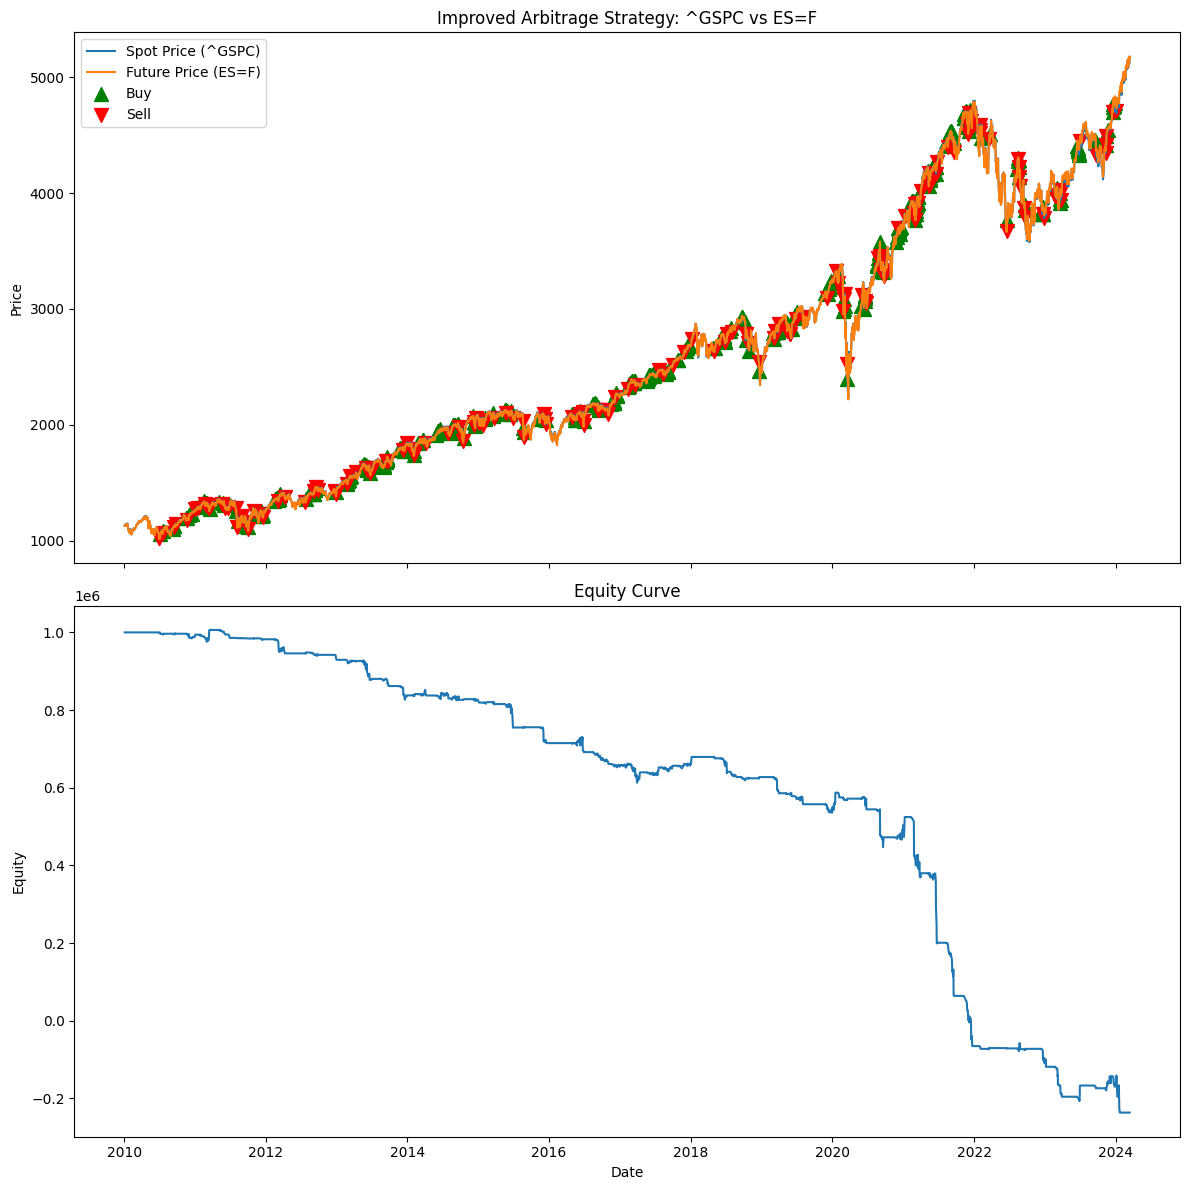

In [28]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from typing import List, Tuple, Dict

class ImprovedArbitrageStrategy:
    def __init__(self, initial_capital: float, max_position: int, 
                 commission_rate: float, slippage: float):
        self.initial_capital = initial_capital
        self.capital = initial_capital
        self.max_position = max_position
        self.commission_rate = commission_rate
        self.slippage = slippage
        self.positions: Dict[str, int] = {}
        self.trades: List[Tuple] = []
        self.equity_curve = []

    def download_data(self, tickers: List[str], start_date: str, end_date: str) -> pd.DataFrame:
        data = yf.download(tickers, start=start_date, end=end_date)['Adj Close']
        return data.dropna()

    def calculate_spread(self, df: pd.DataFrame, spot_col: str, future_col: str) -> pd.Series:
        return df[future_col] - df[spot_col]

    def calculate_position_size(self, spread, mean_spread, std_spread):
        z_score = (spread - mean_spread) / std_spread
        base_position = self.max_position / 2
        position_size = int(base_position * (1 + abs(z_score)))
        return min(position_size, self.max_position)

    def check_stop_loss_take_profit(self, current_price, entry_price, direction, stop_loss_pct=0.01, take_profit_pct=0.02):
        if direction == 'Buy':
            stop_loss = entry_price * (1 - stop_loss_pct)
            take_profit = entry_price * (1 + take_profit_pct)
            return current_price <= stop_loss or current_price >= take_profit
        elif direction == 'Sell':
            stop_loss = entry_price * (1 + stop_loss_pct)
            take_profit = entry_price * (1 - take_profit_pct)
            return current_price >= stop_loss or current_price <= take_profit

    def calculate_multi_period_signals(self, spread, windows=[20, 50, 100]):
        signals = pd.DataFrame()
        for window in windows:
            mean_spread = spread.rolling(window=window).mean()
            std_spread = spread.rolling(window=window).std()
            z_score = (spread - mean_spread) / std_spread
            signals[f'signal_{window}'] = z_score
        return signals.mean(axis=1)

    def adjust_threshold(self, std_spread, base_threshold=1.5, max_threshold=3.0):
        volatility = std_spread.rolling(window=20).mean() / std_spread.rolling(window=100).mean()
        return pd.Series([min(base_threshold * v, max_threshold) for v in volatility], index=std_spread.index)

    def calculate_trend(self, prices, window=50):
        return prices.rolling(window=window).mean().pct_change()

    def optimize_trade_size(self, price, desired_quantity):
        min_trade_cost = price * desired_quantity * self.commission_rate
        if min_trade_cost < 1:  # 최소 거래 비용이 1달러 미만일 경우
            return max(int(1 / (price * self.commission_rate)), desired_quantity)
        return desired_quantity

    def execute_trade(self, date: datetime, asset: str, direction: str, 
                      price: float, quantity: int) -> None:
        optimized_quantity = self.optimize_trade_size(price, quantity)
        transaction_cost = price * optimized_quantity * (self.commission_rate + self.slippage)
        
        if direction == 'Buy':
            self.capital -= price * optimized_quantity + transaction_cost
            self.positions[asset] = self.positions.get(asset, 0) + optimized_quantity
        elif direction == 'Sell':
            self.capital += price * optimized_quantity - transaction_cost
            self.positions[asset] = self.positions.get(asset, 0) - optimized_quantity

        self.trades.append((date, asset, direction, price, optimized_quantity, transaction_cost))

    def calculate_portfolio_value(self, prices: pd.Series) -> float:
        return self.capital + sum(self.positions.get(asset, 0) * prices[asset] for asset in self.positions)

    def run_strategy(self, df: pd.DataFrame, spot_col: str, future_col: str) -> None:
        print("DataFrame columns:", df.columns)
        print("DataFrame info:")
        print(df.info())
        
        spread = self.calculate_spread(df, spot_col, future_col)
        multi_period_signal = self.calculate_multi_period_signals(spread)
        threshold = self.adjust_threshold(spread.rolling(window=20).std())
        trend = self.calculate_trend(df[spot_col])

        for date, row in df.iterrows():
            spot_price = row[spot_col]
            future_price = row[future_col]
            current_spread = future_price - spot_price

            # Check for stop loss / take profit
            for asset, position in list(self.positions.items()):
                if position != 0:
                    entry_price = next(trade[3] for trade in reversed(self.trades) if trade[1] == asset)
                    if self.check_stop_loss_take_profit(row[asset], entry_price, 'Buy' if position > 0 else 'Sell'):
                        self.execute_trade(date, asset, 'Sell' if position > 0 else 'Buy', row[asset], abs(position))

            if abs(multi_period_signal.loc[date]) > threshold.loc[date]:
                position_size = self.calculate_position_size(current_spread, spread.rolling(window=20).mean().loc[date], 
                                                             spread.rolling(window=20).std().loc[date])

                if multi_period_signal.loc[date] > threshold.loc[date] and trend.loc[date] > 0:
                    # Sell future, buy spot
                    self.execute_trade(date, future_col, 'Sell', future_price, position_size)
                    self.execute_trade(date, spot_col, 'Buy', spot_price, position_size)
                elif multi_period_signal.loc[date] < -threshold.loc[date] and trend.loc[date] < 0:
                    # Buy future, sell spot
                    self.execute_trade(date, future_col, 'Buy', future_price, position_size)
                    self.execute_trade(date, spot_col, 'Sell', spot_price, position_size)

            self.equity_curve.append(self.calculate_portfolio_value(row))

    def close_positions(self, df: pd.DataFrame) -> None:
        last_prices = df.iloc[-1]
        for asset, position in self.positions.items():
            if position != 0:
                self.execute_trade(df.index[-1], asset, 'Sell' if position > 0 else 'Buy', 
                                   last_prices[asset], abs(position))
        self.positions.clear()
        self.equity_curve.append(self.capital)

    def calculate_performance(self) -> Dict[str, float]:
        returns = (self.capital - self.initial_capital) / self.initial_capital
        daily_returns = pd.Series(self.equity_curve).pct_change().dropna()
        sharpe_ratio = np.sqrt(252) * daily_returns.mean() / daily_returns.std()
        max_drawdown = (pd.Series(self.equity_curve).cummax() - self.equity_curve).max() / pd.Series(self.equity_curve).cummax()

        return {
            'Total Return': returns * 100,
            'Sharpe Ratio': sharpe_ratio,
            'Max Drawdown': max_drawdown * 100,
            'Number of Trades': len(self.trades)
        }

    def plot_results(self, df: pd.DataFrame, spot_col: str, future_col: str) -> None:
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12), sharex=True)

        ax1.plot(df.index, df[spot_col], label=f'Spot Price ({spot_col})')
        ax1.plot(df.index, df[future_col], label=f'Future Price ({future_col})')
        
        buy_dates = [trade[0] for trade in self.trades if trade[2] == 'Buy' and trade[1] == spot_col]
        buy_prices = [trade[3] for trade in self.trades if trade[2] == 'Buy' and trade[1] == spot_col]
        sell_dates = [trade[0] for trade in self.trades if trade[2] == 'Sell' and trade[1] == spot_col]
        sell_prices = [trade[3] for trade in self.trades if trade[2] == 'Sell' and trade[1] == spot_col]

        ax1.scatter(buy_dates, buy_prices, color='g', marker='^', s=100, label='Buy')
        ax1.scatter(sell_dates, sell_prices, color='r', marker='v', s=100, label='Sell')
        
        ax1.set_ylabel('Price')
        ax1.legend()
        ax1.set_title(f'Improved Arbitrage Strategy: {spot_col} vs {future_col}')

        ax2.plot(df.index, self.equity_curve[:-1])
        ax2.set_ylabel('Equity')
        ax2.set_xlabel('Date')
        ax2.set_title('Equity Curve')

        plt.tight_layout()
        plt.show()

if __name__ == "__main__":
    start_date = '2010-01-01'
    end_date = '2024-03-14'
    spot_ticker = '^GSPC'
    future_ticker = 'ES=F'

    strategy = ImprovedArbitrageStrategy(initial_capital=1000000, max_position=100, 
                                         commission_rate=0.001, slippage=0.0005)
    
    df = strategy.download_data([spot_ticker, future_ticker], start_date, end_date)
    
    strategy.run_strategy(df, spot_ticker, future_ticker)
    strategy.close_positions(df)
    
    performance = strategy.calculate_performance()
    
    print("Improved Arbitrage Strategy Results")
    print("===================================")
    print(f"Initial Capital: ${strategy.initial_capital:,.2f}")
    print(f"Final Capital: ${strategy.capital:,.2f}")
    for metric, value in performance.items():
        if isinstance(value, (int, float)):
            print(f"{metric}: {value:.2f}")
        else:
            print(f"{metric}: {value}")
    
    strategy.plot_results(df, spot_ticker, future_ticker)

In [35]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from typing import List, Tuple, Dict

class ImprovedArbitrageStrategy:
    def __init__(self, initial_capital: float, max_position: int, 
                 commission_rate: float, slippage: float):
        self.initial_capital = initial_capital
        self.capital = initial_capital
        self.max_position = max_position
        self.commission_rate = commission_rate
        self.slippage = slippage
        self.positions: Dict[str, int] = {}
        self.trades: List[Tuple] = []
        self.equity_curve = []

    def download_data(self, tickers: List[str], start_date: str, end_date: str) -> pd.DataFrame:
        data = yf.download(tickers, start=start_date, end=end_date)['Adj Close']
        return data.dropna()

    def calculate_spread(self, df: pd.DataFrame, spot_col: str, future_col: str) -> pd.Series:
        return df[future_col] - df[spot_col]

    def calculate_position_size(self, spread, mean_spread, std_spread):
        z_score = (spread - mean_spread) / std_spread
        base_position = self.max_position / 2
        position_size = int(base_position * (1 + abs(z_score)))
        return min(position_size, self.max_position)

    def check_stop_loss_take_profit(self, current_price, entry_price, direction, stop_loss_pct=0.01, take_profit_pct=0.02):
        if direction == 'Buy':
            stop_loss = entry_price * (1 - stop_loss_pct)
            take_profit = entry_price * (1 + take_profit_pct)
            return current_price <= stop_loss or current_price >= take_profit
        elif direction == 'Sell':
            stop_loss = entry_price * (1 + stop_loss_pct)
            take_profit = entry_price * (1 - take_profit_pct)
            return current_price >= stop_loss or current_price <= take_profit

    def calculate_multi_period_signals(self, spread, windows=[5, 20, 100]):
        signals = pd.DataFrame()
        for window in windows:
            mean_spread = spread.rolling(window=window).mean()
            std_spread = spread.rolling(window=window).std()
            z_score = (spread - mean_spread) / std_spread
            signals[f'signal_{window}'] = z_score
        return signals.mean(axis=1)

    def adjust_threshold(self, std_spread, base_threshold=1.5, max_threshold=3.0):
        volatility = std_spread.rolling(window=20).mean() / std_spread.rolling(window=100).mean()
        return pd.Series([min(base_threshold * v, max_threshold) for v in volatility], index=std_spread.index)

    def calculate_trend(self, prices, window=50):
        return prices.rolling(window=window).mean().pct_change()

    def optimize_trade_size(self, price, desired_quantity):
        min_trade_cost = price * desired_quantity * self.commission_rate
        if min_trade_cost < 1:  # 최소 거래 비용이 1달러 미만일 경우
            return max(int(1 / (price * self.commission_rate)), desired_quantity)
        return desired_quantity

    def execute_trade(self, date: datetime, asset: str, direction: str, 
                      price: float, quantity: int) -> None:
        optimized_quantity = self.optimize_trade_size(price, quantity)
        transaction_cost = price * optimized_quantity * (self.commission_rate + self.slippage)
        
        if direction == 'Buy':
            self.capital -= price * optimized_quantity + transaction_cost
            self.positions[asset] = self.positions.get(asset, 0) + optimized_quantity
        elif direction == 'Sell':
            self.capital += price * optimized_quantity - transaction_cost
            self.positions[asset] = self.positions.get(asset, 0) - optimized_quantity

        self.trades.append((date, asset, direction, price, optimized_quantity, transaction_cost))

    def calculate_portfolio_value(self, prices: pd.Series) -> float:
        return self.capital + sum(self.positions.get(asset, 0) * prices[asset] for asset in self.positions)

    def run_strategy(self, df: pd.DataFrame, spot_col: str, future_col: str) -> None:
        spread = self.calculate_spread(df, spot_col, future_col)
        multi_period_signal = self.calculate_multi_period_signals(spread)
        threshold = self.adjust_threshold(spread.rolling(window=20).std())
        trend = self.calculate_trend(df[spot_col])

        for date, row in df.iterrows():
            spot_price = row[spot_col]
            future_price = row[future_col]
            current_spread = future_price - spot_price

            # Check for stop loss / take profit
            for asset, position in list(self.positions.items()):
                if position != 0:
                    entry_price = next(trade[3] for trade in reversed(self.trades) if trade[1] == asset)
                    if self.check_stop_loss_take_profit(row[asset], entry_price, 'Buy' if position > 0 else 'Sell'):
                        self.execute_trade(date, asset, 'Sell' if position > 0 else 'Buy', row[asset], abs(position))

            if abs(multi_period_signal.loc[date]) > threshold.loc[date]:
                position_size = self.calculate_position_size(current_spread, spread.rolling(window=20).mean().loc[date], 
                                                             spread.rolling(window=20).std().loc[date])

                if multi_period_signal.loc[date] > threshold.loc[date] and trend.loc[date] > 0:
                    # Sell future, buy spot
                    self.execute_trade(date, future_col, 'Sell', future_price, position_size)
                    self.execute_trade(date, spot_col, 'Buy', spot_price, position_size)
                elif multi_period_signal.loc[date] < -threshold.loc[date] and trend.loc[date] < 0:
                    # Buy future, sell spot
                    self.execute_trade(date, future_col, 'Buy', future_price, position_size)
                    self.execute_trade(date, spot_col, 'Sell', spot_price, position_size)

            self.equity_curve.append(self.calculate_portfolio_value(row))

    def close_positions(self, df: pd.DataFrame) -> None:
        last_prices = df.iloc[-1]
        for asset, position in self.positions.items():
            if position != 0:
                self.execute_trade(df.index[-1], asset, 'Sell' if position > 0 else 'Buy', 
                                   last_prices[asset], abs(position))
        self.positions.clear()
        self.equity_curve.append(self.capital)

    def calculate_performance(self) -> Dict[str, float]:
        returns = (self.capital - self.initial_capital) / self.initial_capital
        daily_returns = pd.Series(self.equity_curve).pct_change().dropna()
        sharpe_ratio = np.sqrt(252) * daily_returns.mean() / daily_returns.std()
        max_drawdown = (pd.Series(self.equity_curve).cummax() - self.equity_curve).max() / pd.Series(self.equity_curve).cummax()

        return {
            'Total Return': returns * 100,
            'Sharpe Ratio': sharpe_ratio,
            'Max Drawdown': max_drawdown * 100,
            'Number of Trades': len(self.trades)
        }

    def plot_results(self, df: pd.DataFrame, spot_col: str, future_col: str) -> None:
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12), sharex=True)

        ax1.plot(df.index, df[spot_col], label=f'Spot Price ({spot_col})')
        ax1.plot(df.index, df[future_col], label=f'Future Price ({future_col})')
        
        buy_dates = [trade[0] for trade in self.trades if trade[2] == 'Buy' and trade[1] == spot_col]
        buy_prices = [trade[3] for trade in self.trades if trade[2] == 'Buy' and trade[1] == spot_col]
        sell_dates = [trade[0] for trade in self.trades if trade[2] == 'Sell' and trade[1] == spot_col]
        sell_prices = [trade[3] for trade in self.trades if trade[2] == 'Sell' and trade[1] == spot_col]

        ax1.scatter(buy_dates, buy_prices, color='g', marker='^', s=100, label='Buy')
        ax1.scatter(sell_dates, sell_prices, color='r', marker='v', s=100, label='Sell')
        
        ax1.set_ylabel('Price')
        ax1.legend()
        ax1.set_title(f'Improved Arbitrage Strategy: {spot_col} vs {future_col}')

        ax2.plot(df.index, self.equity_curve[:-1])
        ax2.set_ylabel('Equity')
        ax2.set_xlabel('Date')
        ax2.set_title('Equity Curve')

        plt.tight_layout()
        plt.show()



[*********************100%%**********************]  2 of 2 completed


Improved Arbitrage Strategy Results
Initial Capital: $1,000,000.00
Final Capital: $1,171,459.13
Total Return: 17.15
Sharpe Ratio: 0.85
Max Drawdown: 0      9.402532
1      9.402532
2      9.402532
3      9.402532
4      9.402532
         ...   
621    7.929286
622    7.929286
623    7.929286
624    7.929286
625    7.929286
Length: 626, dtype: float64
Number of Trades: 127.00


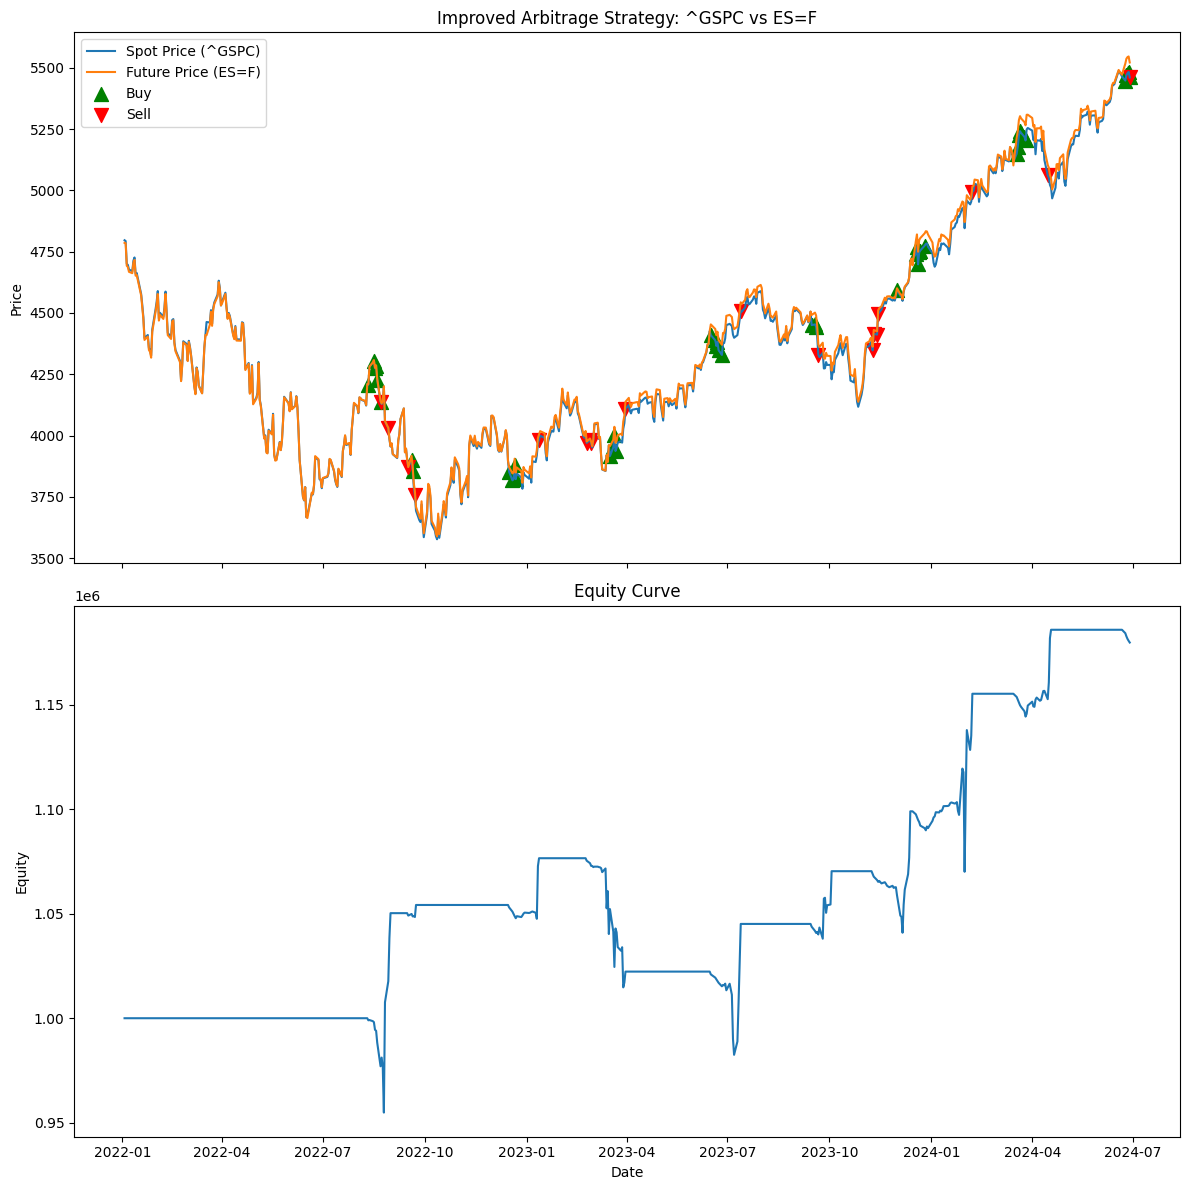

In [45]:
if __name__ == "__main__":
    start_date = '2022-01-01'
    end_date = '2024-07-1'
    spot_ticker = '^GSPC'
    future_ticker = 'ES=F'

    strategy = ImprovedArbitrageStrategy(initial_capital=1000000, max_position=100, 
                                         commission_rate=0.001, slippage=0.0005)
    
    df = strategy.download_data([spot_ticker, future_ticker], start_date, end_date)
    
    strategy.run_strategy(df, spot_ticker, future_ticker)
    strategy.close_positions(df)
    
    performance = strategy.calculate_performance()
    
    print("Improved Arbitrage Strategy Results")
    print("===================================")
    print(f"Initial Capital: ${strategy.initial_capital:,.2f}")
    print(f"Final Capital: ${strategy.capital:,.2f}")
    for metric, value in performance.items():
        if isinstance(value, (int, float)):
            print(f"{metric}: {value:.2f}")
        else:
            print(f"{metric}: {value}")
    
    strategy.plot_results(df, spot_ticker, future_ticker)


[*********************100%%**********************]  2 of 2 completed


Improved Arbitrage Strategy Results
Initial Capital: $1,000,000.00
Final Capital: $1,171,459.13
Total Return: 17.15
Sharpe Ratio: 0.85
Max Drawdown: 0      9.402532
1      9.402532
2      9.402532
3      9.402532
4      9.402532
         ...   
621    7.929286
622    7.929286
623    7.929286
624    7.929286
625    7.929286
Length: 626, dtype: float64
Number of Trades: 127.00


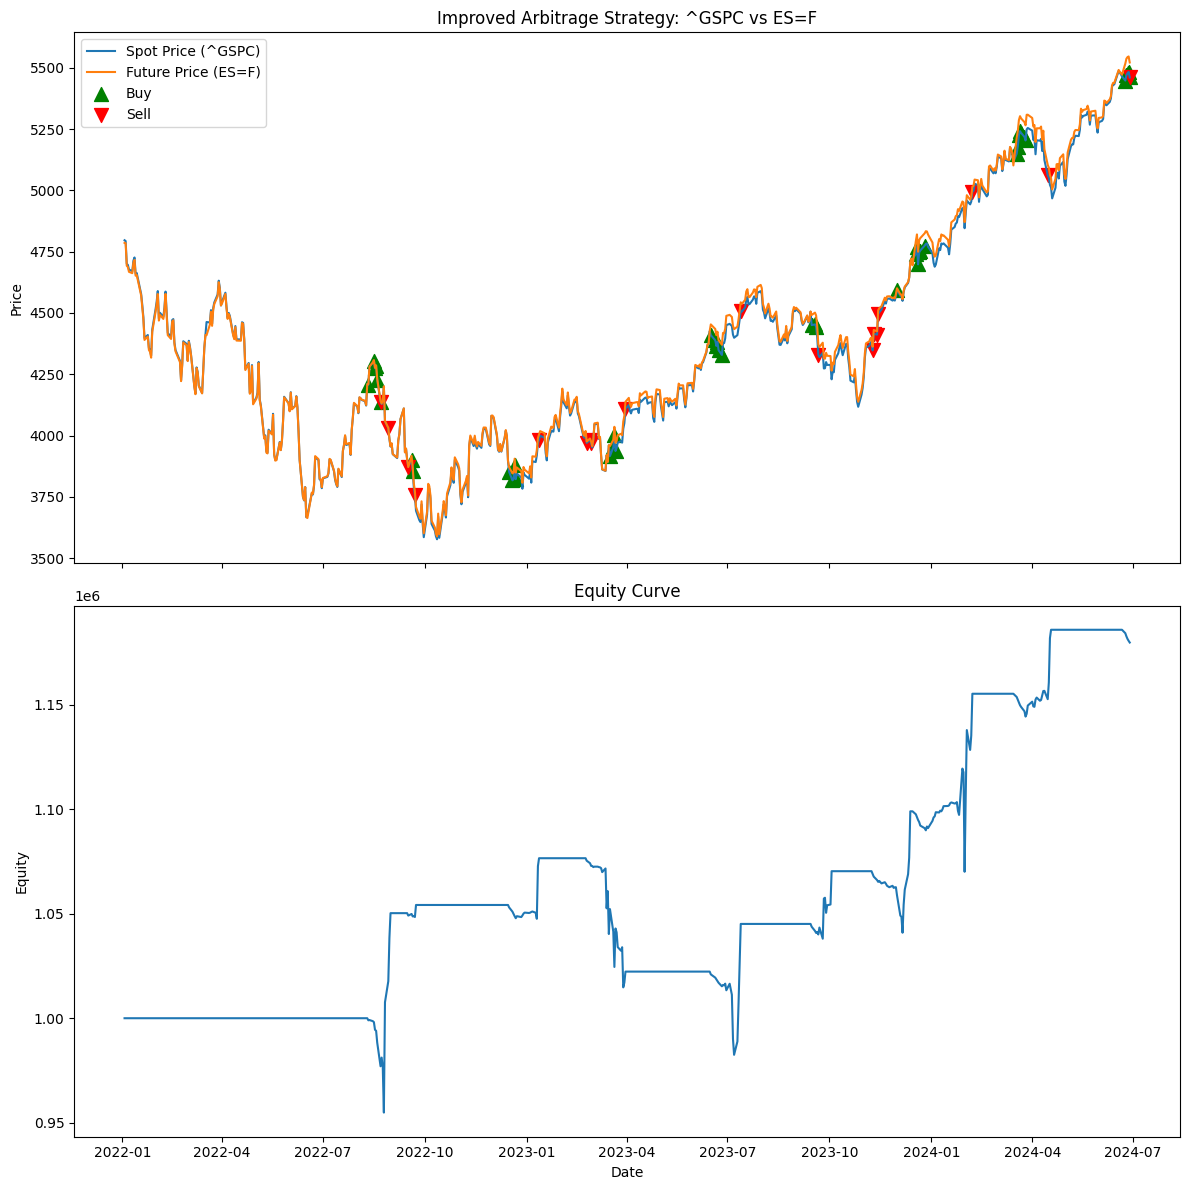

In [44]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from typing import List, Tuple, Dict

class ImprovedArbitrageStrategy:
    def __init__(self, initial_capital: float, max_position: int, 
                 commission_rate: float, slippage: float):
        self.initial_capital = initial_capital
        self.capital = initial_capital
        self.max_position = max_position
        self.commission_rate = commission_rate
        self.slippage = slippage
        self.positions: Dict[str, int] = {}
        self.trades: List[Tuple] = []
        self.equity_curve = []

    def download_data(self, tickers: List[str], start_date: str, end_date: str) -> pd.DataFrame:
        data = yf.download(tickers, start=start_date, end=end_date)['Adj Close']
        return data.dropna()

    def calculate_spread(self, df: pd.DataFrame, spot_col: str, future_col: str) -> pd.Series:
        return df[future_col] - df[spot_col]

    def calculate_position_size(self, spread, mean_spread, std_spread):
        z_score = (spread - mean_spread) / std_spread
        base_position = self.max_position / 2
        position_size = int(base_position * (1 + abs(z_score)))
        return min(position_size, self.max_position)

    def check_stop_loss_take_profit(self, current_price, entry_price, direction, stop_loss_pct=0.02, take_profit_pct=0.04):
        if direction == 'Buy':
            stop_loss = entry_price * (1 - stop_loss_pct)
            take_profit = entry_price * (1 + take_profit_pct)
            return current_price <= stop_loss or current_price >= take_profit
        elif direction == 'Sell':
            stop_loss = entry_price * (1 + stop_loss_pct)
            take_profit = entry_price * (1 - take_profit_pct)
            return current_price >= stop_loss or current_price <= take_profit

    def calculate_multi_period_signals(self, spread, windows=[20, 50, 100]):
        signals = pd.DataFrame()
        for window in windows:
            mean_spread = spread.rolling(window=window).mean()
            std_spread = spread.rolling(window=window).std()
            z_score = (spread - mean_spread) / std_spread
            signals[f'signal_{window}'] = z_score
        return signals.mean(axis=1)

    def adjust_threshold(self, std_spread, base_threshold=1.5, max_threshold=3.0):
        volatility = std_spread.rolling(window=20).mean() / std_spread.rolling(window=100).mean()
        return pd.Series([min(base_threshold * v, max_threshold) for v in volatility], index=std_spread.index)

    def calculate_trend(self, prices, window=50):
        return prices.rolling(window=window).mean().pct_change()

    def optimize_trade_size(self, price, desired_quantity):
        min_trade_cost = price * desired_quantity * self.commission_rate
        if min_trade_cost < 1:  # 최소 거래 비용이 1달러 미만일 경우
            return max(int(1 / (price * self.commission_rate)), desired_quantity)
        return desired_quantity

    def execute_trade(self, date: datetime, asset: str, direction: str, 
                      price: float, quantity: int) -> None:
        optimized_quantity = self.optimize_trade_size(price, quantity)
        transaction_cost = price * optimized_quantity * (self.commission_rate + self.slippage)
        
        if direction == 'Buy':
            self.capital -= price * optimized_quantity + transaction_cost
            self.positions[asset] = self.positions.get(asset, 0) + optimized_quantity
        elif direction == 'Sell':
            self.capital += price * optimized_quantity - transaction_cost
            self.positions[asset] = self.positions.get(asset, 0) - optimized_quantity

        self.trades.append((date, asset, direction, price, optimized_quantity, transaction_cost))

    def calculate_portfolio_value(self, prices: pd.Series) -> float:
        return self.capital + sum(self.positions.get(asset, 0) * prices[asset] for asset in self.positions)

    def run_strategy(self, df: pd.DataFrame, spot_col: str, future_col: str) -> None:
        spread = self.calculate_spread(df, spot_col, future_col)
        multi_period_signal = self.calculate_multi_period_signals(spread)
        threshold = self.adjust_threshold(spread.rolling(window=20).std())
        trend = self.calculate_trend(df[spot_col])

        for date, row in df.iterrows():
            spot_price = row[spot_col]
            future_price = row[future_col]
            current_spread = future_price - spot_price

            # Check for stop loss / take profit
            for asset, position in list(self.positions.items()):
                if position != 0:
                    entry_price = next(trade[3] for trade in reversed(self.trades) if trade[1] == asset)
                    if self.check_stop_loss_take_profit(row[asset], entry_price, 'Buy' if position > 0 else 'Sell'):
                        self.execute_trade(date, asset, 'Sell' if position > 0 else 'Buy', row[asset], abs(position))

            if abs(multi_period_signal.loc[date]) > threshold.loc[date]:
                position_size = self.calculate_position_size(current_spread, spread.rolling(window=20).mean().loc[date], 
                                                             spread.rolling(window=20).std().loc[date])

                if multi_period_signal.loc[date] > threshold.loc[date] and trend.loc[date] > 0:
                    # Sell future, buy spot
                    self.execute_trade(date, future_col, 'Sell', future_price, position_size)
                    self.execute_trade(date, spot_col, 'Buy', spot_price, position_size)
                elif multi_period_signal.loc[date] < -threshold.loc[date] and trend.loc[date] < 0:
                    # Buy future, sell spot
                    self.execute_trade(date, future_col, 'Buy', future_price, position_size)
                    self.execute_trade(date, spot_col, 'Sell', spot_price, position_size)

            self.equity_curve.append(self.calculate_portfolio_value(row))

    def close_positions(self, df: pd.DataFrame) -> None:
        last_prices = df.iloc[-1]
        for asset, position in self.positions.items():
            if position != 0:
                self.execute_trade(df.index[-1], asset, 'Sell' if position > 0 else 'Buy', 
                                   last_prices[asset], abs(position))
        self.positions.clear()
        self.equity_curve.append(self.capital)

    def calculate_performance(self) -> Dict[str, float]:
        returns = (self.capital - self.initial_capital) / self.initial_capital
        daily_returns = pd.Series(self.equity_curve).pct_change().dropna()
        sharpe_ratio = np.sqrt(252) * daily_returns.mean() / daily_returns.std()
        max_drawdown = (pd.Series(self.equity_curve).cummax() - self.equity_curve).max() / pd.Series(self.equity_curve).cummax()

        return {
            'Total Return': returns * 100,
            'Sharpe Ratio': sharpe_ratio,
            'Max Drawdown': max_drawdown * 100,
            'Number of Trades': len(self.trades)
        }

    def plot_results(self, df: pd.DataFrame, spot_col: str, future_col: str) -> None:
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12), sharex=True)

        ax1.plot(df.index, df[spot_col], label=f'Spot Price ({spot_col})')
        ax1.plot(df.index, df[future_col], label=f'Future Price ({future_col})')
        
        buy_dates = [trade[0] for trade in self.trades if trade[2] == 'Buy' and trade[1] == spot_col]
        buy_prices = [trade[3] for trade in self.trades if trade[2] == 'Buy' and trade[1] == spot_col]
        sell_dates = [trade[0] for trade in self.trades if trade[2] == 'Sell' and trade[1] == spot_col]
        sell_prices = [trade[3] for trade in self.trades if trade[2] == 'Sell' and trade[1] == spot_col]

        ax1.scatter(buy_dates, buy_prices, color='g', marker='^', s=100, label='Buy')
        ax1.scatter(sell_dates, sell_prices, color='r', marker='v', s=100, label='Sell')
        
        ax1.set_ylabel('Price')
        ax1.legend()
        ax1.set_title(f'Improved Arbitrage Strategy: {spot_col} vs {future_col}')

        ax2.plot(df.index, self.equity_curve[:-1])
        ax2.set_ylabel('Equity')
        ax2.set_xlabel('Date')
        ax2.set_title('Equity Curve')

        plt.tight_layout()
        plt.show()

if __name__ == "__main__":
    start_date = '2022-01-01'
    end_date = '2024-07-1'
    spot_ticker = '^GSPC'
    future_ticker = 'ES=F'

    strategy = ImprovedArbitrageStrategy(initial_capital=1000000, max_position=100, 
                                         commission_rate=0.001, slippage=0.0005)
    
    df = strategy.download_data([spot_ticker, future_ticker], start_date, end_date)
    
    strategy.run_strategy(df, spot_ticker, future_ticker)
    strategy.close_positions(df)
    
    performance = strategy.calculate_performance()
    
    print("Improved Arbitrage Strategy Results")
    print("===================================")
    print(f"Initial Capital: ${strategy.initial_capital:,.2f}")
    print(f"Final Capital: ${strategy.capital:,.2f}")
    for metric, value in performance.items():
        if isinstance(value, (int, float)):
            print(f"{metric}: {value:.2f}")
        else:
            print(f"{metric}: {value}")
    
    strategy.plot_results(df, spot_ticker, future_ticker)


In [67]:
import yfinance as yf
import pandas as pd

def download_data(tickers: List[str], start_date: str, end_date: str) -> pd.DataFrame:
    data = yf.download(tickers, start=start_date, end=end_date)['Adj Close']
    return data.dropna()

start_date = '2022-01-01'
end_date = '2024-07-01'
spot_ticker = '^GSPC'
future_ticker = 'ES=F'

df = download_data([spot_ticker, future_ticker], start_date, end_date)


[*********************100%%**********************]  2 of 2 completed


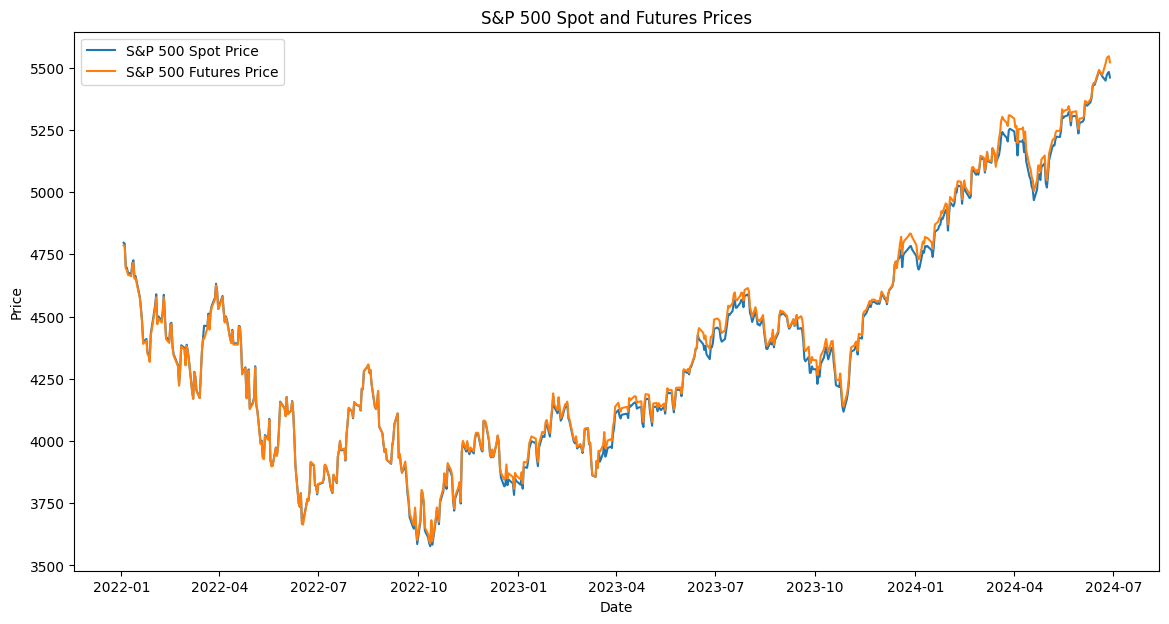

In [68]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))
plt.plot(df.index, df[spot_ticker], label='S&P 500 Spot Price')
plt.plot(df.index, df[future_ticker], label='S&P 500 Futures Price')
plt.xlabel('Date')
plt.ylabel('Price')
plt.title('S&P 500 Spot and Futures Prices')
plt.legend()
plt.show()


In [69]:
def calculate_spread(df: pd.DataFrame, spot_col: str, future_col: str) -> pd.Series:
    return df[future_col] - df[spot_col]

spread = calculate_spread(df, spot_ticker, future_ticker)


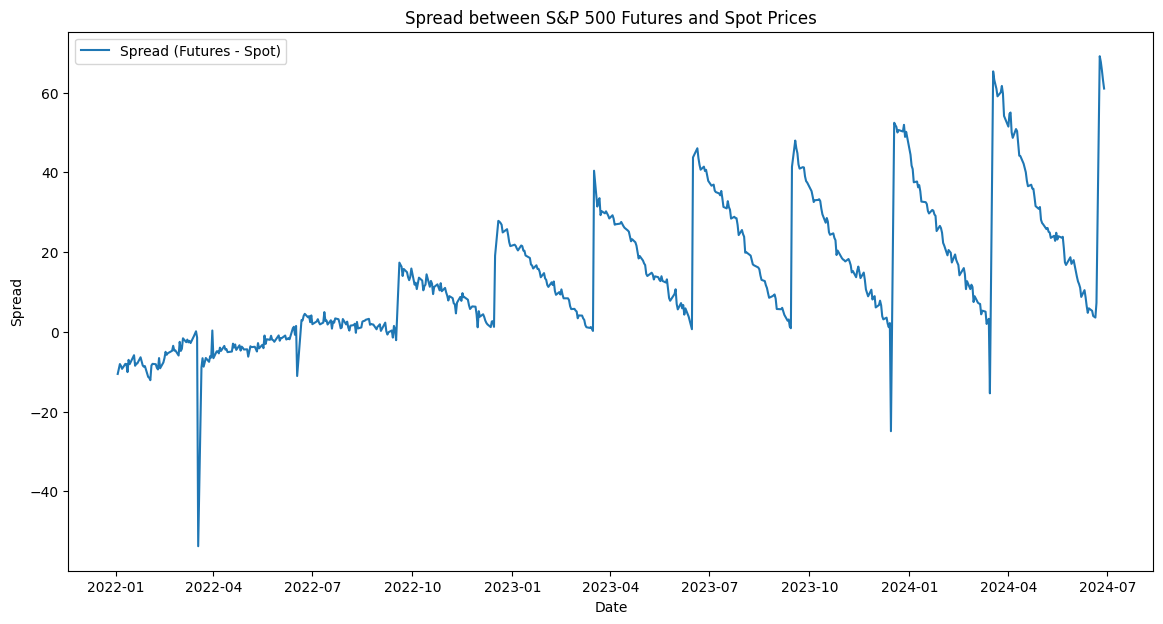

In [70]:
plt.figure(figsize=(14, 7))
plt.plot(df.index, spread, label='Spread (Futures - Spot)')
plt.xlabel('Date')
plt.ylabel('Spread')
plt.title('Spread between S&P 500 Futures and Spot Prices')
plt.legend()
plt.show()


In [71]:
def calculate_position_size(spread, mean_spread, std_spread):
    z_score = (spread - mean_spread) / std_spread
    base_position = self.max_position / 2
    position_size = int(base_position * (1 + abs(z_score)))
    return min(position_size, self.max_position)


In [72]:
def check_stop_loss_take_profit(self, current_price, entry_price, direction, stop_loss_pct=0.02, take_profit_pct=0.04):
    # 손절매 및 이익 실현 비율을 증가시켰습니다.
    if direction == 'Buy':
        stop_loss = entry_price * (1 - stop_loss_pct)
        take_profit = entry_price * (1 + take_profit_pct)
        return current_price <= stop_loss or current_price >= take_profit
    elif direction == 'Sell':
        stop_loss = entry_price * (1 + stop_loss_pct)
        take_profit = entry_price * (1 - take_profit_pct)
        return current_price >= stop_loss or current_price <= take_profit



In [73]:
def calculate_multi_period_signals(spread, windows=[20, 50, 100]):
    signals = pd.DataFrame()
    for window in windows:
        mean_spread = spread.rolling(window=window).mean()
        std_spread = spread.rolling(window=window).std()
        z_score = (spread - mean_spread) / std_spread
        signals[f'signal_{window}'] = z_score
    return signals.mean(axis=1)

multi_period_signal = calculate_multi_period_signals(spread)


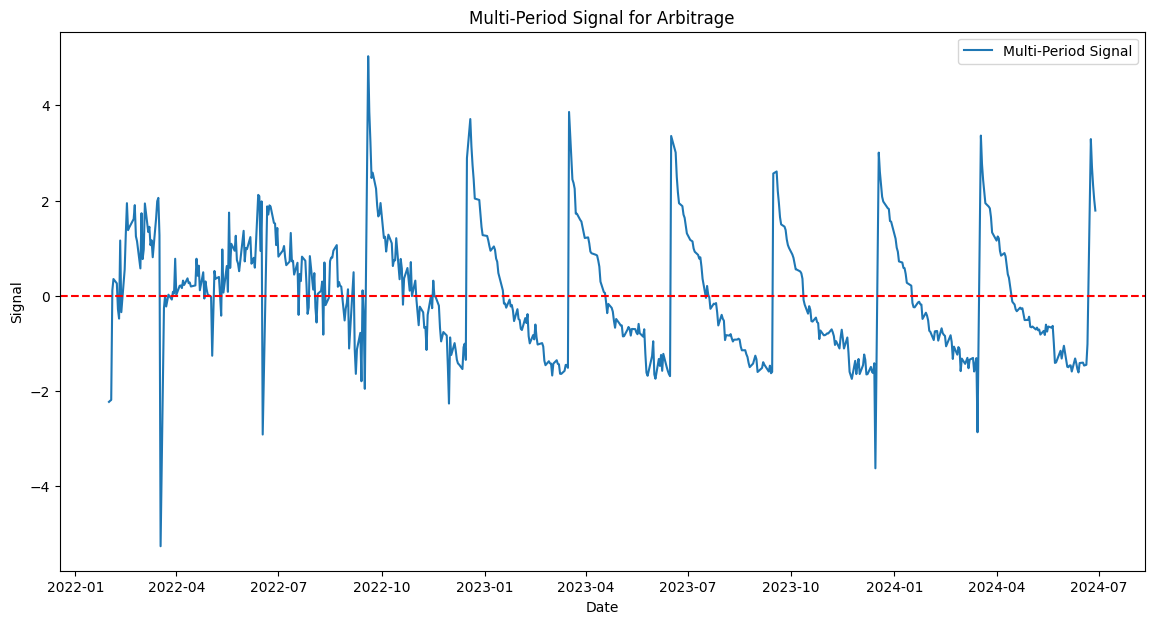

In [74]:
plt.figure(figsize=(14, 7))
plt.plot(multi_period_signal.index, multi_period_signal, label='Multi-Period Signal')
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Date')
plt.ylabel('Signal')
plt.title('Multi-Period Signal for Arbitrage')
plt.legend()
plt.show()


In [75]:
def adjust_threshold(std_spread, base_threshold=1.5, max_threshold=3.0):
    volatility = std_spread.rolling(window=20).mean() / std_spread.rolling(window=100).mean()
    return pd.Series([min(base_threshold * v, max_threshold) for v in volatility], index=std_spread.index)

threshold = adjust_threshold(spread.rolling(window=20).std())


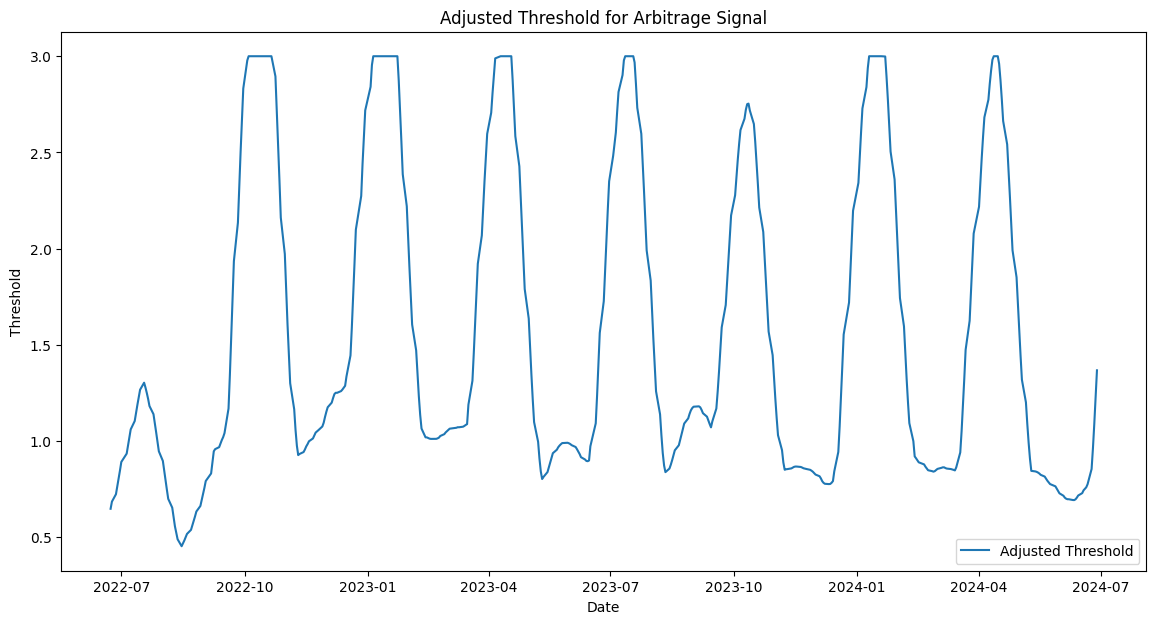

In [76]:
plt.figure(figsize=(14, 7))
plt.plot(threshold.index, threshold, label='Adjusted Threshold')
plt.xlabel('Date')
plt.ylabel('Threshold')
plt.title('Adjusted Threshold for Arbitrage Signal')
plt.legend()
plt.show()


In [77]:
def calculate_trend(prices, window=50):
    return prices.rolling(window=window).mean().pct_change()

trend = calculate_trend(df[spot_ticker])


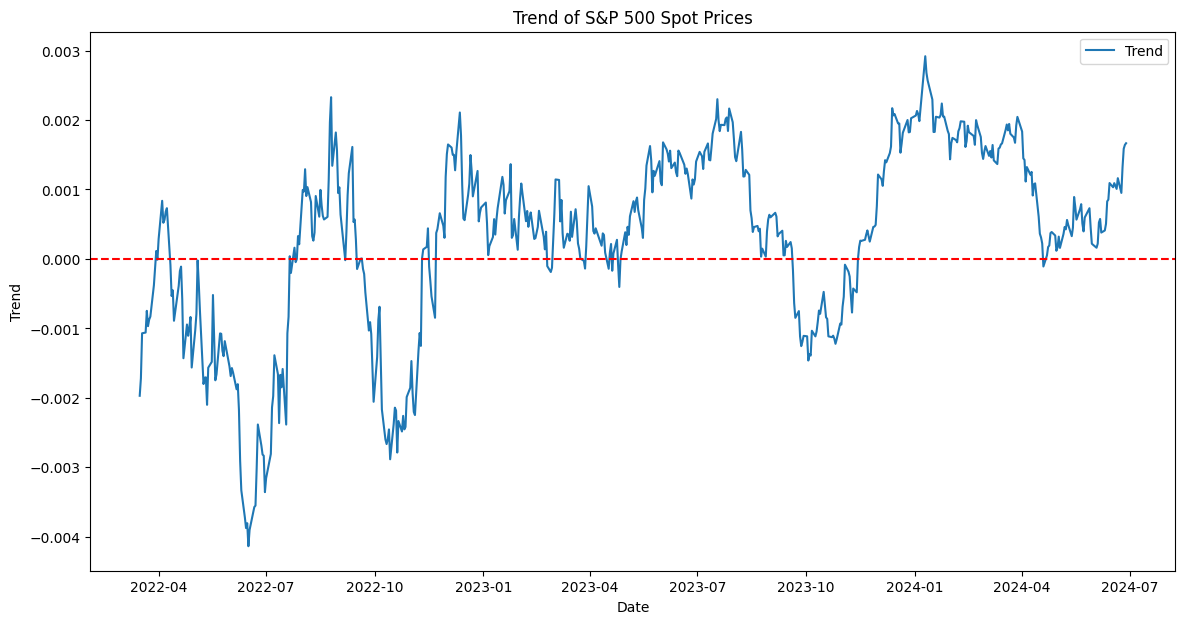

In [78]:
plt.figure(figsize=(14, 7))
plt.plot(trend.index, trend, label='Trend')
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Date')
plt.ylabel('Trend')
plt.title('Trend of S&P 500 Spot Prices')
plt.legend()
plt.show()


In [79]:
def optimize_trade_size(self, price, desired_quantity):
    min_trade_cost = price * desired_quantity * self.commission_rate
    if min_trade_cost < 1:  # 최소 거래 비용이 1달러 미만일 경우
        return max(int(1 / (price * self.commission_rate)), desired_quantity)
    return desired_quantity


In [80]:
def execute_trade(self, date: datetime, asset: str, direction: str, price: float, quantity: int) -> None:
    optimized_quantity = self.optimize_trade_size(price, quantity)
    transaction_cost = price * optimized_quantity * (self.commission_rate + self.slippage)
    
    if direction == 'Buy':
        self.capital -= price * optimized_quantity + transaction_cost
        self.positions[asset] = self.positions.get(asset, 0) + optimized_quantity
    elif direction == 'Sell':
        self.capital += price * optimized_quantity - transaction_cost
        self.positions[asset] = self.positions.get(asset, 0) - optimized_quantity

    self.trades.append((date, asset, direction, price, optimized_quantity, transaction_cost))


In [81]:
def run_strategy(self, df: pd.DataFrame, spot_col: str, future_col: str) -> None:
    spread = self.calculate_spread(df, spot_col, future_col)
    multi_period_signal = self.calculate_multi_period_signals(spread)
    threshold = self.adjust_threshold(spread.rolling(window=20).std())
    trend = self.calculate_trend(df[spot_col])

    for date, row in df.iterrows():
        spot_price = row[spot_col]
        future_price = row[future_col]
        current_spread = future_price - spot_price

        # Check for stop loss / take profit
        for asset, position in list(self.positions.items()):
            if position != 0:
                entry_price = next(trade[3] for trade in reversed(self.trades) if trade[1] == asset)
                if self.check_stop_loss_take_profit(row[asset], entry_price, 'Buy' if position > 0 else 'Sell'):
                    self.execute_trade(date, asset, 'Sell' if position > 0 else 'Buy', row[asset], abs(position))

        if abs(multi_period_signal.loc[date]) > threshold.loc[date]:
            position_size = self.calculate_position_size(current_spread, spread.rolling(window=20).mean().loc[date], 
                                                         spread.rolling(window=20).std().loc[date])

            if multi_period_signal.loc[date] > threshold.loc[date] and trend.loc[date] > 0:
                # Sell future, buy spot
                self.execute_trade(date, future_col, 'Sell', future_price, position_size)
                self.execute_trade(date, spot_col, 'Buy', spot_price, position_size)
            elif multi_period_signal.loc[date] < -threshold.loc[date] and trend.loc[date] < 0:
                # Buy future, sell spot
                self.execute_trade(date, future_col, 'Buy', future_price, position_size)
                self.execute_trade(date, spot_col, 'Sell', spot_price, position_size)

        self.equity_curve.append(self.calculate_portfolio_value(row))


In [82]:
def close_positions(self, df: pd.DataFrame) -> None:
    last_prices = df.iloc[-1]
    for asset, position in self.positions.items():
        if position != 0:
            self.execute_trade(df.index[-1], asset, 'Sell' if position > 0 else 'Buy', 
                               last_prices[asset], abs(position))
    self.positions.clear()
    self.equity_curve.append(self.capital)


In [83]:
def calculate_performance(self) -> Dict[str, float]:
    returns = (self.capital - self.initial_capital) / self.initial_capital
    daily_returns = pd.Series(self.equity_curve).pct_change().dropna()
    sharpe_ratio = np.sqrt(252) * daily_returns.mean() / daily_returns.std()
    max_drawdown = (pd.Series(self.equity_curve).cummax() - self.equity_curve).max() / pd.Series(self.equity_curve).cummax()

    return {
        'Total Return': returns * 100,
        'Sharpe Ratio': sharpe_ratio,
        'Max Drawdown': max_drawdown * 100,
        'Number of Trades': len(self.trades)
    }


In [84]:
def plot_results(self, df: pd.DataFrame, spot_col: str, future_col: str) -> None:
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12), sharex=True)

    ax1.plot(df.index, df[spot_col], label=f'Spot Price ({spot_col})')
    ax1.plot(df.index, df[future_col], label=f'Future Price ({future_col})')
    
    buy_dates = [trade[0] for trade in self.trades if trade[2] == 'Buy' and trade[1] == spot_col]
    buy_prices = [trade[3] for trade in self.trades if trade[2] == 'Buy' and trade[1] == spot_col]
    sell_dates = [trade[0] for trade in self.trades if trade[2] == 'Sell' and trade[1] == spot_col]
    sell_prices = [trade[3] for trade in self.trades if trade[2] == 'Sell' and trade[1] == spot_col]

    ax1.scatter(buy_dates, buy_prices, color='g', marker='^', s=100, label='Buy')
    ax1.scatter(sell_dates, sell_prices, color='r', marker='v', s=100, label='Sell')
    
    ax1.set_ylabel('Price')
    ax1.legend()
    ax1.set_title(f'Improved Arbitrage Strategy: {spot_col} vs {future_col}')

    ax2.plot(df.index, self.equity_curve[:-1])
    ax2.set_ylabel('Equity')
    ax2.set_xlabel('Date')
    ax2.set_title('Equity Curve')

    plt.tight_layout()
    plt.show()


[*********************100%%**********************]  2 of 2 completed

Improved Arbitrage Strategy Results
Initial Capital: $1,000,000.00
Final Capital: $1,171,459.13
Total Return: 17.15
Sharpe Ratio: 0.85
Max Drawdown: 0      9.402532
1      9.402532
2      9.402532
3      9.402532
4      9.402532
         ...   
621    7.929286
622    7.929286
623    7.929286
624    7.929286
625    7.929286
Length: 626, dtype: float64
Number of Trades: 127.00


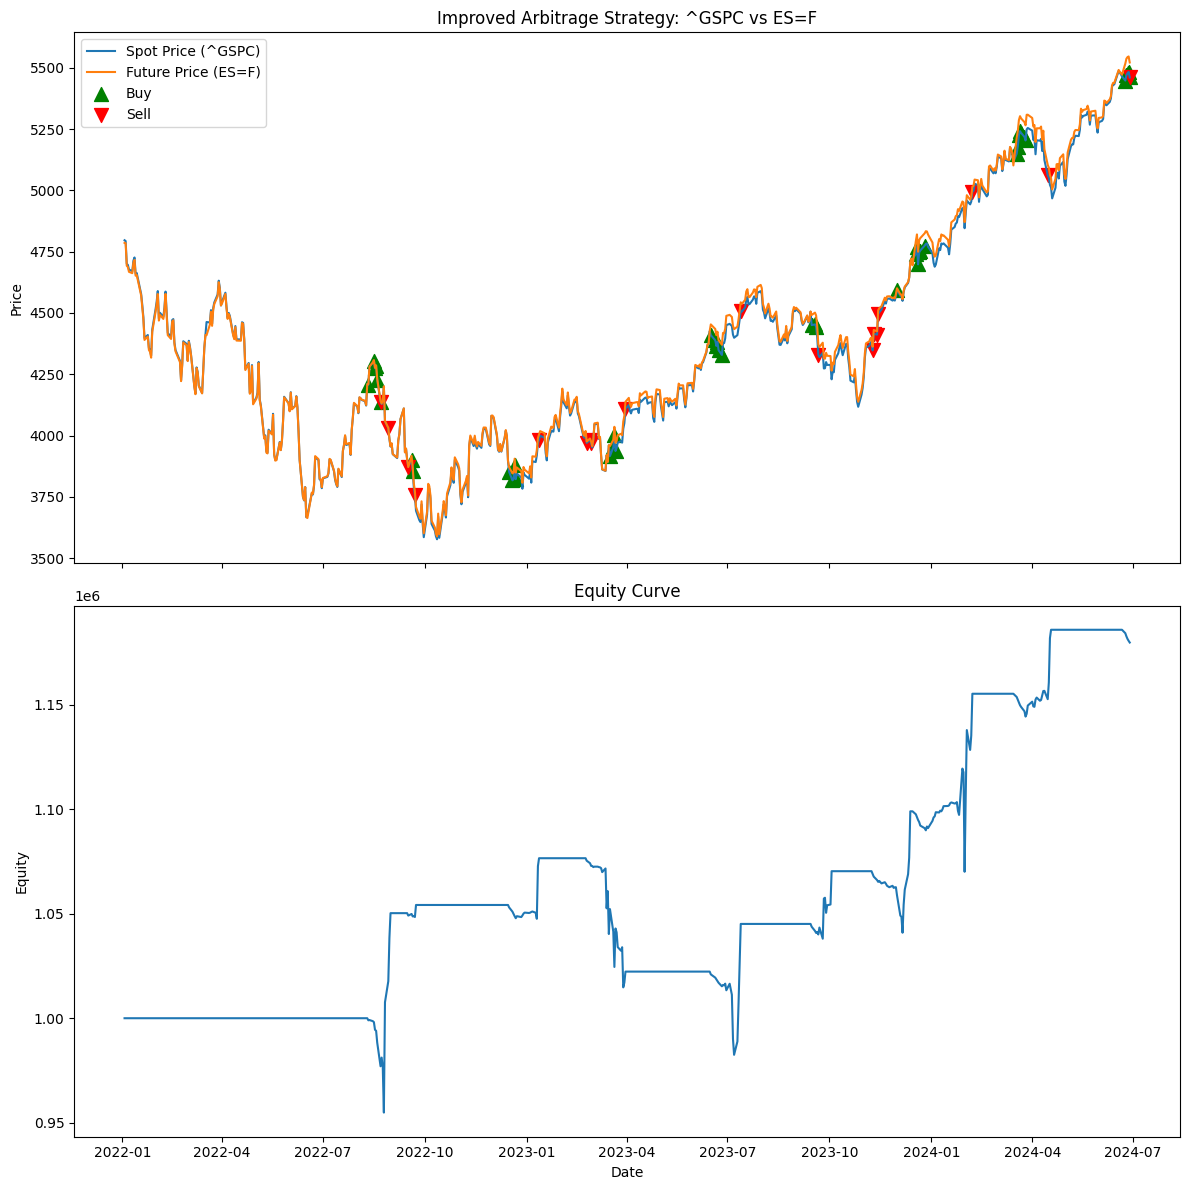

In [85]:
if __name__ == "__main__":
    start_date = '2022-01-01'
    end_date = '2024-07-01'
    spot_ticker = '^GSPC'
    future_ticker = 'ES=F'

    strategy = ImprovedArbitrageStrategy(initial_capital=1000000, max_position=100, 
                                         commission_rate=0.001, slippage=0.0005)
    
    df = strategy.download_data([spot_ticker, future_ticker], start_date, end_date)
    
    strategy.run_strategy(df, spot_ticker, future_ticker)
    strategy.close_positions(df)
    
    performance = strategy.calculate_performance()
    
    print("Improved Arbitrage Strategy Results")
    print("===================================")
    print(f"Initial Capital: ${strategy.initial_capital:,.2f}")
    print(f"Final Capital: ${strategy.capital:,.2f}")
    for metric, value in performance.items():
        if isinstance(value, (int, float)):
            print(f"{metric}: {value:.2f}")
        else:
            print(f"{metric}: {value}")

    
    strategy.plot_results(df, spot_ticker, future_ticker)
